# ASD Training + Music Generation Notebook

ASD project model training, prediction under simulated ASD conditions, and music generation

- 49 physiological features per window
- 12-window input sequences
- train-participant-only `RobustScaler`
- GRU-based emotion model
- MSE loss first, without uncertainty/NLL during initial training
- optional MC-dropout uncertainty

If you want to re-run cached output from a previous training + prediction run:
- Run all cells in order, EXCEPT:
    * Section 9, `training code`
    * Section 15, `Save preprocessing and label-normalization objects`
    * Section 17, `cell to save trial features for each ASD condition as well as save the sample trial indices`

## 1. Mount Drive and set paths

Edit `PROJECT_DIR` only if your Drive folder is different.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_DIR = '/content/drive/MyDrive/2025/ASD_Project/DEAP_Data'
DEAP_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'deap-dataset', 'data_preprocessed_python')
FEATURE_DIR = os.path.join(PROJECT_DIR, 'features')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
MIDI_DIR = os.path.join(PROJECT_DIR, 'midi_output')
CACHE_DIR = os.path.join(PROJECT_DIR, 'cache')

for d in [FEATURE_DIR, MODEL_DIR, RESULTS_DIR, MIDI_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

print('PROJECT_DIR:', PROJECT_DIR)
print('DEAP_DATA_PATH:', DEAP_DATA_PATH)
print('FEATURE_DIR:', FEATURE_DIR)

# Experiment configuration
EXPECTED_DIM = 49
hidden = 256
drop = 0.15
RUN_ID = f"meanstd_mlp_{hidden}_{drop}_zlabel"

print("RUN_ID:", RUN_ID)


Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data
DEAP_DATA_PATH: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/data/deap-dataset/data_preprocessed_python
FEATURE_DIR: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/features
RUN_ID: meanstd_mlp_256_0.15_zlabel


## 2. Imports and constants


In [ ]:
import os, pickle, json, math, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import signal, stats
from scipy.signal import welch, find_peaks, coherence, butter, filtfilt, iirnotch
from scipy.ndimage import median_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import joblib
from tqdm.notebook import tqdm

SEED = 43
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

EXPECTED_DIM = 49
SEQ_LEN = 12


Device: cpu


## 3. Load cached windowed features

This assumes your cached files are named like `pid1_features.npz`, `pid2_features.npz`, etc., and each contains:

- `features`: shape `(40, 29, 49)` or similar
- `labels`: shape `(40, 4)` with valence/arousal/dominance/liking

The notebook uses only valence and arousal.


In [ ]:
import os
import glob
import re
import numpy as np

FEATURE_DIR = "/content/drive/MyDrive/2025/ASD_Project/ASD_features"
EXPECTED_DIM = 49

def get_pid_from_filename(path):
    """
    Tries to extract participant ID from filenames like:
    pid01_features.npz
    participant_1_features.npz
    s01_features.npz
    01_features.npz
    """
    name = os.path.basename(path)

    patterns = [
        r"pid(\d+)",
        r"participant[_-]?(\d+)",
        r"subject[_-]?(\d+)",
        r"s(\d+)",
        r"^(\d+)"
    ]

    for pat in patterns:
        m = re.search(pat, name, re.IGNORECASE)
        if m:
            return int(m.group(1))

    return None


def load_cached_features(feature_dir=FEATURE_DIR, expected_dim=EXPECTED_DIM):
    files = sorted(glob.glob(os.path.join(feature_dir, "*.npz")))

    print("Feature directory:", feature_dir)
    print("Number of .npz files found:", len(files))

    if len(files) == 0:
        print("No .npz files found.")
        print("Check whether FEATURE_DIR is correct.")
        print("Folder contents:")
        if os.path.exists(feature_dir):
            print(os.listdir(feature_dir)[:50])
        else:
            print("Folder does not exist.")
        raise FileNotFoundError("No cached feature .npz files found.")

    print("First few files:")
    for f in files[:10]:
        print(" ", os.path.basename(f))

    all_features = []
    all_labels = []
    all_pids = []

    for path in files:
        data = np.load(path, allow_pickle=True)

        print("\nReading:", os.path.basename(path))
        print("Keys:", list(data.keys()))

        # Try common key names
        if "features" in data:
            features = data["features"]
        elif "X" in data:
            features = data["X"]
        elif "all_features" in data:
            features = data["all_features"]
        else:
            raise KeyError(f"No feature key found in {path}. Available keys: {list(data.keys())}")

        if "labels" in data:
            labels = data["labels"]
        elif "y" in data:
            labels = data["y"]
        elif "targets" in data:
            labels = data["targets"]
        else:
            raise KeyError(f"No label key found in {path}. Available keys: {list(data.keys())}")

        features = np.asarray(features, dtype=np.float32)
        labels = np.asarray(labels, dtype=np.float32)

        print(" features shape:", features.shape)
        print(" labels shape:", labels.shape)

        pid = get_pid_from_filename(path)

        if pid is None:
            pid = len(set(all_pids)) + 1
            print(" Could not infer PID from filename; assigning PID:", pid)
        else:
            print(" PID:", pid)

        # Case A: one file contains all 40 trials for one participant
        # Expected shape: (40, 29, 49), labels: (40, 2)
        if features.ndim == 3:
            for t in range(features.shape[0]):
                f = features[t]

                if f.shape[-1] > expected_dim:
                    f = f[:, :expected_dim]

                if f.shape[-1] != expected_dim:
                    raise ValueError(f"Feature dim mismatch in {path}, trial {t}: {f.shape}")

                all_features.append(f)
                # all_labels.append(labels[t])
                all_labels.append(labels[t][:2])
                all_pids.append(pid)

        # Case B: one file contains one trial, already windowed
        # Expected shape: (29, 49), labels: (2,)
        elif features.ndim == 2:
            f = features

            if f.shape[-1] > expected_dim:
                f = f[:, :expected_dim]

            if f.shape[-1] != expected_dim:
                raise ValueError(f"Feature dim mismatch in {path}: {f.shape}")

            all_features.append(f)
            all_labels.append(labels)
            all_pids.append(pid)

        # Case C: one file contains one trial, already aggregated
        # Expected shape: (49,), labels: (2,)
        elif features.ndim == 1:
            f = features[:expected_dim].reshape(1, expected_dim)

            all_features.append(f)
            all_labels.append(labels)
            all_pids.append(pid)

        else:
            raise ValueError(f"Unsupported feature shape in {path}: {features.shape}")

    all_labels = np.asarray(all_labels, dtype=np.float32)
    all_pids = np.asarray(all_pids)

    print("\nLoaded trials:", len(all_features))
    print("Labels shape:", all_labels.shape)
    print("PIDs shape:", all_pids.shape)
    print("Example feature shape:", all_features[0].shape)
    print("Unique PIDs:", np.unique(all_pids))

    assert len(all_features) > 0
    assert all_features[0].shape[-1] == expected_dim

    return all_features, all_labels, all_pids


all_features, all_labels_va, all_pids = load_cached_features()

Feature directory: /content/drive/MyDrive/2025/ASD_Project/ASD_features
Number of .npz files found: 32
First few files:
  pid10_features.npz
  pid11_features.npz
  pid12_features.npz
  pid13_features.npz
  pid14_features.npz
  pid15_features.npz
  pid16_features.npz
  pid17_features.npz
  pid18_features.npz
  pid19_features.npz

Reading: pid10_features.npz
Keys: ['features', 'labels']
 features shape: (40, 29, 51)
 labels shape: (40, 4)
 PID: 10

Reading: pid11_features.npz
Keys: ['features', 'labels']
 features shape: (40, 29, 51)
 labels shape: (40, 4)
 PID: 11

Reading: pid12_features.npz
Keys: ['features', 'labels']
 features shape: (40, 29, 51)
 labels shape: (40, 4)
 PID: 12

Reading: pid13_features.npz
Keys: ['features', 'labels']
 features shape: (40, 29, 51)
 labels shape: (40, 4)
 PID: 13

Reading: pid14_features.npz
Keys: ['features', 'labels']
 features shape: (40, 29, 51)
 labels shape: (40, 4)
 PID: 14

Reading: pid15_features.npz
Keys: ['features', 'labels']
 features sh

## 4. Participant-level train/validation/test split

This keeps participants separate across splits.


In [ ]:
def participant_split(all_pids, train_frac=0.70, val_frac=0.10, seed=SEED):
    rng = np.random.default_rng(seed)
    unique_pids = np.unique(all_pids)
    rng.shuffle(unique_pids)

    n = len(unique_pids)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))

    train_pids = set(unique_pids[:n_train])
    val_pids = set(unique_pids[n_train:n_train+n_val])
    test_pids = set(unique_pids[n_train+n_val:])

    train_idx = [i for i, pid in enumerate(all_pids) if pid in train_pids]
    val_idx = [i for i, pid in enumerate(all_pids) if pid in val_pids]
    test_idx = [i for i, pid in enumerate(all_pids) if pid in test_pids]

    print('Train PIDs:', sorted(train_pids))
    print('Val PIDs:', sorted(val_pids))
    print('Test PIDs:', sorted(test_pids))
    print('Train/Val/Test trials:', len(train_idx), len(val_idx), len(test_idx))

    return train_idx, val_idx, test_idx, train_pids, val_pids, test_pids

train_idx, val_idx, test_idx, train_pids, val_pids, test_pids = participant_split(all_pids)


Train PIDs: [np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(24), np.int64(25), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32)]
Val PIDs: [np.int64(15), np.int64(18), np.int64(22)]
Test PIDs: [np.int64(1), np.int64(4), np.int64(5), np.int64(16), np.int64(21), np.int64(23), np.int64(26)]
Train/Val/Test trials: 880 120 280


## 5. Train-only RobustScaler

The scaler is fit only on training windows, then applied unchanged to train/val/test.


In [ ]:
def fit_train_scaler(all_features, train_idx):
    train_windows = np.concatenate([all_features[i] for i in train_idx], axis=0)
    print('Training windows for scaler:', train_windows.shape)
    scaler = RobustScaler()
    scaler.fit(train_windows)
    return scaler

scaler = fit_train_scaler(all_features, train_idx)

all_features_scaled = [scaler.transform(x).astype(np.float32) for x in all_features]

# scaler = fit_train_scaler(all_features_norm, train_idx)

# all_features_scaled = [
#     scaler.transform(x).astype(np.float32)
#     for x in all_features_norm
# ]

scaler_path = os.path.join(MODEL_DIR, 'clean_feature_scaler_49.joblib')
joblib.dump(scaler, scaler_path)
print('Saved scaler:', scaler_path)


Training windows for scaler: (25520, 49)
Saved scaler: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/models/clean_feature_scaler_49.joblib


## 6. Dataset and collate functions

Training uses random 12-window crops. Validation/test use a center crop for stable evaluation.


In [ ]:
class EmotionWindowDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        x = np.asarray(self.features[idx], dtype=np.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


def make_sequence(x, seq_len=SEQ_LEN, expected_dim=EXPECTED_DIM, mode='center'):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x = x[:, :expected_dim]

    T, F = x.shape
    out = np.zeros((seq_len, expected_dim), dtype=np.float32)

    if T >= seq_len:
        if mode == 'random':
            start = np.random.randint(0, T - seq_len + 1)
        elif mode == 'last':
            start = T - seq_len
        else:
            start = (T - seq_len) // 2
        out[:] = x[start:start+seq_len]
    else:
        out[:T] = x

    return out


def collate_train(batch):
    features, labels = zip(*batch)
    x = np.stack([make_sequence(f, mode='random') for f in features], axis=0)
    y = torch.stack(labels)
    return torch.tensor(x, dtype=torch.float32), y


def collate_eval(batch):
    features, labels = zip(*batch)
    x = np.stack([make_sequence(f, mode='center') for f in features], axis=0)
    y = torch.stack(labels)
    return torch.tensor(x, dtype=torch.float32), y


dataset = EmotionWindowDataset(all_features_scaled, all_labels_va)
train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_train)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, collate_fn=collate_eval)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, collate_fn=collate_eval)

xb, yb = next(iter(train_loader))
print('Batch x:', xb.shape)
print('Batch y:', yb.shape)
assert xb.shape[1:] == (SEQ_LEN, EXPECTED_DIM)


Batch x: torch.Size([64, 12, 49])
Batch y: torch.Size([64, 2])


In [ ]:
# Labels for each split
train_labels = all_labels_va[train_idx]
val_labels = all_labels_va[val_idx]
test_labels = all_labels_va[test_idx]

print("Train labels:", train_labels.shape)
print("Val labels:", val_labels.shape)
print("Test labels:", test_labels.shape)

print("Train label mean/std:", train_labels.mean(axis=0), train_labels.std(axis=0))
print("Val label mean/std:", val_labels.mean(axis=0), val_labels.std(axis=0))
print("Test label mean/std:", test_labels.mean(axis=0), test_labels.std(axis=0))

label_mean = torch.tensor(train_labels.mean(axis=0), dtype=torch.float32, device=device)
label_std = torch.tensor(train_labels.std(axis=0), dtype=torch.float32, device=device)

print("label_mean:", label_mean)
print("label_std:", label_std)

Train labels: (880, 2)
Val labels: (120, 2)
Test labels: (280, 2)
Train label mean/std: [0.31030676 0.35300428] [0.24787399 0.25458726]
Val label mean/std: [0.32454166 0.38092703] [0.25599918 0.20463963]
Test label mean/std: [0.29450887 0.2873437 ] [0.25836453 0.2327458 ]
label_mean: tensor([0.3103, 0.3530])
label_std: tensor([0.2479, 0.2546])


## 7. Simple GRU emotion model

This is intentionally much smaller than the hybrid CNN-LSTM-Transformer. It should be easier to debug and less likely to overfit.


In [ ]:
class SimpleGRUEmotionModel(nn.Module):
    def __init__(self, input_dim=EXPECTED_DIM, hidden_dim=64, gru_hidden=64, num_layers=1, dropout=0.25):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=gru_hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.head = nn.Sequential(
            nn.LayerNorm(gru_hidden * 2),
            nn.Linear(gru_hidden * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_norm(x)
        x = self.input_proj(x)
        h, _ = self.gru(x)
        pooled = h.mean(dim=1)
        pred_z = self.head(pooled)
        return {'va': pred_z, 'valence': pred_z[:, 0], 'arousal': pred_z[:, 1]}



class MeanStdMLP(nn.Module):
    """
    Input:  (batch, seq_len, input_dim)
    Output: dict with key 'va', shape (batch, 2)
    """

    def __init__(self, input_dim=49, hidden_dim=64, dropout=0.30):
        super().__init__()

        self.input_dim = input_dim
        self.summary_dim = input_dim * 2

        self.net = nn.Sequential(
            nn.Linear(self.summary_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, 2),

        )

    def forward(self, x):
        x_mean = x.mean(dim=1)
        x_std = x.std(dim=1, unbiased=False)
        z = torch.cat([x_mean, x_std], dim=1)

        pred = self.net(z)
        return {'va': pred}


# model = SimpleGRUEmotionModel(input_dim=EXPECTED_DIM).to(device)
# n_params = sum(p.numel() for p in model.parameters())
# print('Parameters:', f'{n_params:,}')

# with torch.no_grad():
#     test_out = model(xb.to(device))
# print('Forward output:', test_out['va'].shape)


## 8. Training and evaluation helpers


In [ ]:
def safe_corr(y_true, y_pred):
    if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return np.nan
    return pearsonr(y_true, y_pred)[0]


def loss_fn(pred_z, y):
    y_z = (y - label_mean) / label_std
    return F.mse_loss(pred_z, y_z)


def evaluate(model, loader, device=device):
    model.eval()
    preds, trues = [], []
    total_loss = 0.0
    n = 0
    mse = nn.MSELoss(reduction='sum')

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            # model predicts standardized labels
            pred_z = model(x)['va']

            # convert back to original [0, 1] scale
            pred = pred_z * label_std + label_mean
            pred = torch.clamp(pred, 0.0, 1.0)

            # evaluate in original label scale
            loss = mse(pred, y)
            total_loss += loss.item()
            n += y.numel()

            preds.append(pred.cpu().numpy())
            trues.append(y.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)

    metrics = {
        'mse': total_loss / n,
        'rmse_valence': float(np.sqrt(mean_squared_error(trues[:,0], preds[:,0]))),
        'rmse_arousal': float(np.sqrt(mean_squared_error(trues[:,1], preds[:,1]))),
        'mae_valence': float(mean_absolute_error(trues[:,0], preds[:,0])),
        'mae_arousal': float(mean_absolute_error(trues[:,1], preds[:,1])),
        'corr_valence': float(safe_corr(trues[:,0], preds[:,0])),
        'corr_arousal': float(safe_corr(trues[:,1], preds[:,1])),
        'pred_valence_std': float(np.std(preds[:,0])),
        'pred_arousal_std': float(np.std(preds[:,1])),
        'true_valence_std': float(np.std(trues[:,0])),
        'true_arousal_std': float(np.std(trues[:,1])),
    }

    return metrics, preds, trues

def train_one_epoch(model, loader, optimizer, device=device, grad_clip=1.0):
    model.train()
    total = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        # pred = model(x)['va']

        pred_z = model(x)['va']
        loss = loss_fn(pred_z, y)

        # loss = loss_fn(pred, y)
        loss.backward()
        clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total += loss.item()
        n_batches += 1

    return total / max(n_batches, 1)


## 9. Train the simple model

This saves the best checkpoint by combined validation correlation. If correlations are noisy, the MSE checkpoint is also useful.


In [ ]:
# *** for re-runs: run this cell ***

# model = SimpleGRUEmotionModel(input_dim=EXPECTED_DIM, hidden_dim=64, gru_hidden=64, dropout=0.25).to(device)

model = MeanStdMLP(
    input_dim=EXPECTED_DIM,
    hidden_dim=hidden,
    dropout=drop
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

# Forward test
x = torch.randn(8, 12, EXPECTED_DIM, device=device)
out = model(x)

print("Output keys:", out.keys())
print("Output shape:", out['va'].shape)
assert out['va'].shape == (8, 2)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

n_epochs = 100
best_val_mse = float('inf')
best_corr_score = -float('inf')

# mse_ckpt_path = os.path.join(MODEL_DIR, 'clean_simple_gru_best_mse.pt')
# corr_ckpt_path = os.path.join(MODEL_DIR, 'clean_simple_gru_best_corr.pt')


BEST_MSE_PATH = os.path.join(MODEL_DIR, f"{RUN_ID}_best_mse.pt")
BEST_CORR_PATH = os.path.join(MODEL_DIR, f"{RUN_ID}_best_corr.pt")
HISTORY_PATH = os.path.join(RESULTS_DIR, f"{RUN_ID}_history.csv")

Parameters: 59,266
Output keys: dict_keys(['va'])
Output shape: torch.Size([8, 2])


In [ ]:
# *** for re-runs: DO NOT run this cell ***
## training code
history = []

print('Starting training...')
for epoch in range(1, n_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_metrics, _, _ = evaluate(model, val_loader)
    scheduler.step(val_metrics['mse'])

    corr_v = val_metrics['corr_valence']
    corr_a = val_metrics['corr_arousal']
    # corr_score = corr_a
    corr_score = np.nan_to_num(corr_v, nan=-1.0) + np.nan_to_num(corr_a, nan=-1.0)

    if val_metrics['mse'] < best_val_mse:
        best_val_mse = val_metrics['mse']
        torch.save(model.state_dict(), BEST_MSE_PATH)

    if corr_score > best_corr_score:
        best_corr_score = corr_score
        torch.save(model.state_dict(), BEST_CORR_PATH)

    row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics, 'corr_score': corr_score}
    history.append(row)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | train={train_loss:.4f} | val_mse={val_metrics['mse']:.4f} | "
            f"v_corr={corr_v:.3f} | a_corr={corr_a:.3f} | "
            f"pred_std=({val_metrics['pred_valence_std']:.3f}, {val_metrics['pred_arousal_std']:.3f})"
        )

history_df = pd.DataFrame(history)
# history_path = os.path.join(RESULTS_DIR, 'clean_simple_gru_training_history.csv')
history_df.to_csv(HISTORY_PATH, index=False)

print('Saved best MSE model:', BEST_MSE_PATH)
print('Saved best Corr model:', BEST_CORR_PATH)
print('Saved history:', HISTORY_PATH)
print('Best val MSE:', best_val_mse)
print('Best corr score:', best_corr_score)


Starting training...
Epoch 001 | train=1.1097 | val_mse=0.0586 | v_corr=0.055 | a_corr=0.003 | pred_std=(0.050, 0.040)
Epoch 005 | train=0.9461 | val_mse=0.0575 | v_corr=0.083 | a_corr=-0.109 | pred_std=(0.062, 0.059)
Epoch 010 | train=0.9062 | val_mse=0.0616 | v_corr=-0.033 | a_corr=-0.025 | pred_std=(0.066, 0.069)
Epoch 015 | train=0.7963 | val_mse=0.0694 | v_corr=0.007 | a_corr=-0.064 | pred_std=(0.102, 0.100)
Epoch 020 | train=0.7593 | val_mse=0.0723 | v_corr=-0.043 | a_corr=-0.068 | pred_std=(0.122, 0.105)
Epoch 025 | train=0.7140 | val_mse=0.0687 | v_corr=-0.046 | a_corr=-0.008 | pred_std=(0.113, 0.112)
Epoch 030 | train=0.7005 | val_mse=0.0686 | v_corr=-0.013 | a_corr=0.019 | pred_std=(0.114, 0.122)
Epoch 035 | train=0.6760 | val_mse=0.0724 | v_corr=-0.046 | a_corr=-0.025 | pred_std=(0.115, 0.126)
Epoch 040 | train=0.6688 | val_mse=0.0710 | v_corr=-0.021 | a_corr=-0.002 | pred_std=(0.121, 0.127)
Epoch 045 | train=0.6686 | val_mse=0.0724 | v_corr=-0.030 | a_corr=-0.022 | pred_std

## 10. Plot training curves


In [ ]:
## if we want to reload cached data of history_df so that we can run this section:

history_df = pd.read_csv(HISTORY_PATH)

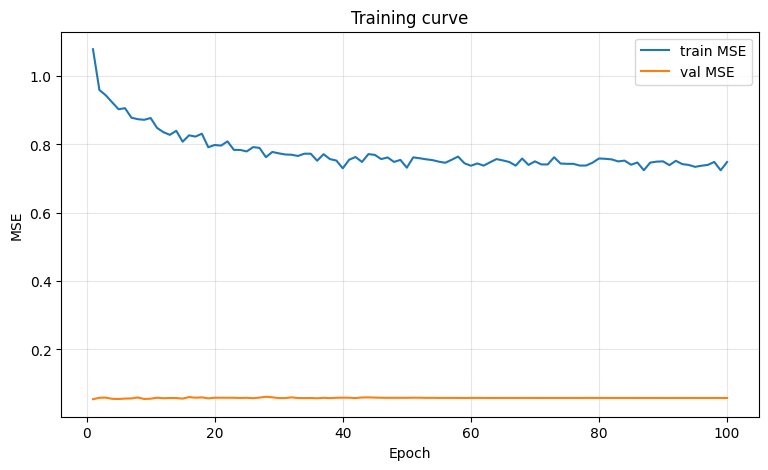

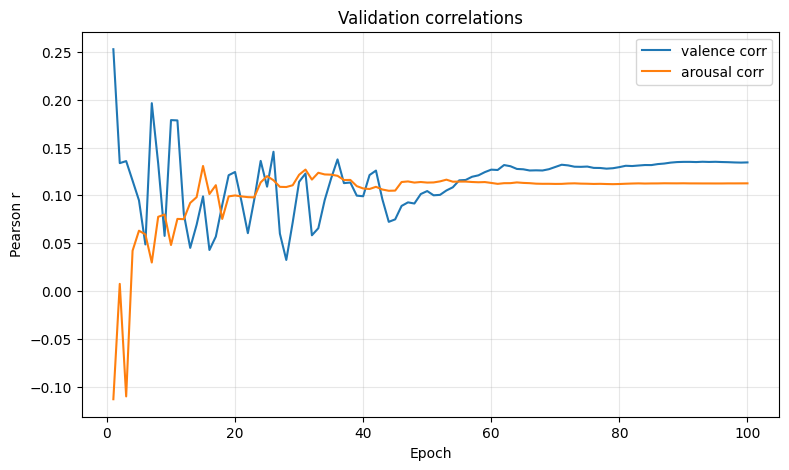

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train MSE')
plt.plot(history_df['epoch'], history_df['mse'], label='val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df['epoch'], history_df['corr_valence'], label='valence corr')
plt.plot(history_df['epoch'], history_df['corr_arousal'], label='arousal corr')
plt.xlabel('Epoch')
plt.ylabel('Pearson r')
plt.title('Validation correlations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Final test evaluation

Use either the correlation-selected checkpoint or the MSE-selected checkpoint. For your project, the correlation checkpoint may be more useful for downstream emotional variation.


In [ ]:
# Choose checkpoint
ckpt_path = BEST_CORR_PATH  # or mse_ckpt_path

# model = SimpleGRUEmotionModel(input_dim=EXPECTED_DIM, hidden_dim=64, gru_hidden=64, dropout=0.25).to(device)

model = MeanStdMLP(
    input_dim=EXPECTED_DIM,
    hidden_dim=hidden,
    dropout=drop
).to(device)

model.load_state_dict(torch.load(ckpt_path, map_location=device))

val_metrics, val_preds, val_trues = evaluate(model, val_loader)
test_metrics, test_preds, test_trues = evaluate(model, test_loader)

print('Checkpoint:', ckpt_path)
print('\nValidation metrics')
for k, v in val_metrics.items():
    print(f'{k}: {v:.4f}')

print('\nTest metrics')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}')

metrics_path = os.path.join(RESULTS_DIR, f'clean_simple_gru_final_metrics_{RUN_ID}.json')
with open(metrics_path, 'w') as f:
    json.dump({'val': val_metrics, 'test': test_metrics, 'checkpoint': ckpt_path}, f, indent=2)
print('\nSaved metrics:', metrics_path)


Checkpoint: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/models/meanstd_mlp_256_0.15_zlabel_best_corr.pt

Validation metrics
mse: 0.0573
rmse_valence: 0.2595
rmse_arousal: 0.2173
mae_valence: 0.2062
mae_arousal: 0.1710
corr_valence: 0.1456
corr_arousal: 0.1158
pred_valence_std: 0.0598
pred_arousal_std: 0.0965
true_valence_std: 0.2560
true_arousal_std: 0.2046

Test metrics
mse: 0.0672
rmse_valence: 0.2658
rmse_arousal: 0.2527
mae_valence: 0.2159
mae_arousal: 0.2142
corr_valence: 0.1331
corr_arousal: 0.0352
pred_valence_std: 0.0787
pred_arousal_std: 0.0697
true_valence_std: 0.2584
true_arousal_std: 0.2327

Saved metrics: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/clean_simple_gru_final_metrics_meanstd_mlp_256_0.15_zlabel.json


## 12. Prediction diagnostics

This checks whether the model is collapsing toward a nearly constant prediction.


--- Validation ---
Valence pred mean/std: 0.27296093 0.059820257
Valence true mean/std: 0.32454166 0.2559992
Arousal pred mean/std: 0.35584813 0.09647262
Arousal true mean/std: 0.3809271 0.20463964
--- Test ---
Valence pred mean/std: 0.35010687 0.07872699
Valence true mean/std: 0.2945089 0.25836453
Arousal pred mean/std: 0.36456442 0.06965983
Arousal true mean/std: 0.28734377 0.2327458

--- Validation Prediction Distribution ---

Valence:
  Mean : 0.272961
  Std  : 0.059820
  Min  : 0.131936
  5%   : 0.167384
  25%  : 0.233100
  50%  : 0.272549
  75%  : 0.315260
  95%  : 0.373605
  Max  : 0.414354

Arousal:
  Mean : 0.355848
  Std  : 0.096473
  Min  : 0.124431
  5%   : 0.220363
  25%  : 0.286060
  50%  : 0.339558
  75%  : 0.442000
  95%  : 0.517733
  Max  : 0.529093

--- Test Prediction Distribution ---

Valence:
  Mean : 0.350107
  Std  : 0.078727
  Min  : 0.119807
  5%   : 0.211860
  25%  : 0.297362
  50%  : 0.348286
  75%  : 0.408064
  95%  : 0.478166
  Max  : 0.543441

Arousal:
  M

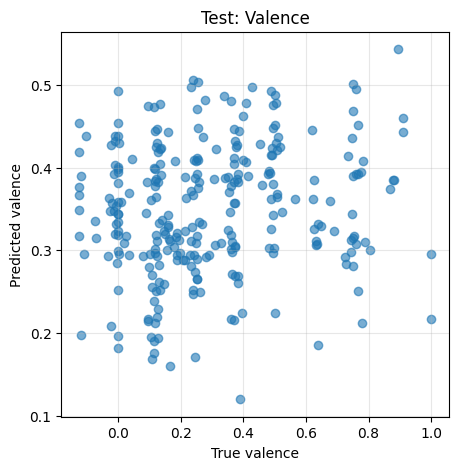

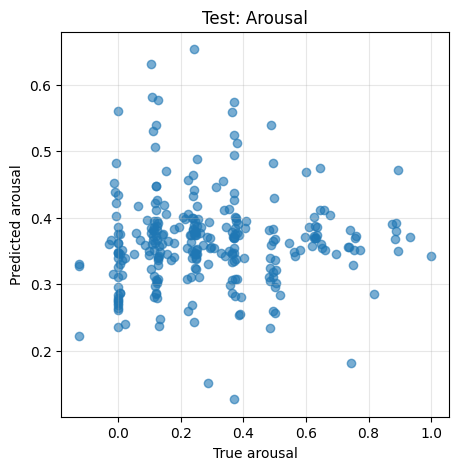

In [ ]:
def print_prediction_summary(name, preds, trues):
    print(f'--- {name} ---')
    print('Valence pred mean/std:', preds[:,0].mean(), preds[:,0].std())
    print('Valence true mean/std:', trues[:,0].mean(), trues[:,0].std())
    print('Arousal pred mean/std:', preds[:,1].mean(), preds[:,1].std())
    print('Arousal true mean/std:', trues[:,1].mean(), trues[:,1].std())

print_prediction_summary('Validation', val_preds, val_trues)
print_prediction_summary('Test', test_preds, test_trues)

def print_prediction_distribution(name, preds):
    print(f"\n--- {name} Prediction Distribution ---")

    for i, emotion in enumerate(["Valence", "Arousal"]):
        x = preds[:, i]

        print(f"\n{emotion}:")
        print(f"  Mean : {np.mean(x):.6f}")
        print(f"  Std  : {np.std(x):.6f}")
        print(f"  Min  : {np.min(x):.6f}")
        print(f"  5%   : {np.percentile(x, 5):.6f}")
        print(f"  25%  : {np.percentile(x, 25):.6f}")
        print(f"  50%  : {np.percentile(x, 50):.6f}")
        print(f"  75%  : {np.percentile(x, 75):.6f}")
        print(f"  95%  : {np.percentile(x, 95):.6f}")
        print(f"  Max  : {np.max(x):.6f}")

print_prediction_distribution("Validation", val_preds)
print_prediction_distribution("Test", test_preds)

plt.figure(figsize=(5,5))
plt.scatter(test_trues[:,0], test_preds[:,0], alpha=0.6)
plt.xlabel('True valence')
plt.ylabel('Predicted valence')
plt.title('Test: Valence')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(test_trues[:,1], test_preds[:,1], alpha=0.6)
plt.xlabel('True arousal')
plt.ylabel('Predicted arousal')
plt.title('Test: Arousal')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# used for downstream music parameter generation

# Use TEST prediction distribution as fixed calibration reference

V_LOW  = np.percentile(test_preds[:,0], 5)
V_HIGH = np.percentile(test_preds[:,0], 95)

A_LOW  = np.percentile(test_preds[:,1], 5)
A_HIGH = np.percentile(test_preds[:,1], 95)

print("Calibration constants:")
print(f"V_LOW  = {V_LOW:.6f}")
print(f"V_HIGH = {V_HIGH:.6f}")
print(f"A_LOW  = {A_LOW:.6f}")
print(f"A_HIGH = {A_HIGH:.6f}")

Calibration constants:
V_LOW  = 0.211860
V_HIGH = 0.478166
A_LOW  = 0.260445
A_HIGH = 0.488734


In [ ]:
train_labels = all_labels_va[train_idx]
val_labels = all_labels_va[val_idx]
test_labels = all_labels_va[test_idx]

print("Train label mean/std:", train_labels.mean(axis=0), train_labels.std(axis=0))
print("Val label mean/std:", val_labels.mean(axis=0), val_labels.std(axis=0))
print("Test label mean/std:", test_labels.mean(axis=0), test_labels.std(axis=0))

print("Train label mean/std:", train_labels.mean(axis=0), train_labels.std(axis=0))
print("Val label mean/std:", val_labels.mean(axis=0), val_labels.std(axis=0))
print("Test label mean/std:", test_labels.mean(axis=0), test_labels.std(axis=0))

Train label mean/std: [0.31030676 0.35300428] [0.24787399 0.25458726]
Val label mean/std: [0.32454166 0.38092703] [0.25599918 0.20463963]
Test label mean/std: [0.29450887 0.2873437 ] [0.25836453 0.2327458 ]
Train label mean/std: [0.31030676 0.35300428] [0.24787399 0.25458726]
Val label mean/std: [0.32454166 0.38092703] [0.25599918 0.20463963]
Test label mean/std: [0.29450887 0.2873437 ] [0.25836453 0.2327458 ]


## 13. Optional: MC-dropout uncertainty

This estimates uncertainty by keeping dropout active at prediction time. Do this only after the plain MSE model is training correctly.


In [ ]:
def predict_with_mc_dropout(model, x_windows, scaler=None, n_samples=20, seq_len=SEQ_LEN, device=device):
    x = np.asarray(x_windows, dtype=np.float32)

    if x.ndim == 1:
        x = x.reshape(1, -1)

    x = x[:, :EXPECTED_DIM]

    if scaler is not None:
        x = scaler.transform(x).astype(np.float32)

    x_seq = make_sequence(x, seq_len=seq_len, expected_dim=EXPECTED_DIM, mode='center')
    x_tensor = torch.tensor(x_seq, dtype=torch.float32).unsqueeze(0).to(device)

    model.train()  # enables dropout for MC-dropout
    preds = []

    with torch.no_grad():
        for _ in range(n_samples):
            pred_z = model(x_tensor)['va']

            # convert standardized prediction back to original [0, 1] scale
            pred = pred_z * label_std + label_mean
            pred = torch.clamp(pred, 0.0, 1.0)

            preds.append(pred.cpu().numpy()[0])

    model.eval()

    preds = np.asarray(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# Example on one scaled test trial, without applying scaler again because all_features_scaled is already scaled
example_idx = test_idx[0]
mean_pred, std_pred = predict_with_mc_dropout(model, all_features_scaled[example_idx], scaler=None, n_samples=20)
print('Mean prediction:', mean_pred)
print('MC-dropout std:', std_pred)


Mean prediction: [0.28548536 0.34817454]
MC-dropout std: [0.02153927 0.02845286]


# Optional ASD-simulation section

The cells below are only needed if you want to re-extract features from raw NT/ASD-simulated signals and compare predictions across severity levels.

Important: this assumes your cached features were created from the same `FeatureExtractor` feature order below.


## 14. Raw DEAP loader and feature extractor classes


In [ ]:
class DEAPDataLoader:
    """
    DEAP dataset loader for preprocessed .dat (pickle) files.

    The DEAP dataset structure:
    - 32 participants (s01.dat to s32.dat)
    - 40 trials per participant (40 music videos)
    - 40 channels: 32 EEG + 8 peripheral (EOG, EMG, GSR, Respiration, etc.)
    - 8064 samples per trial (63 seconds at 128 Hz, including 3s baseline)
    - Labels: valence, arousal, dominance, liking (1-9 scale)
    """

    def __init__(self, data_dir=None, cache_dir=CACHE_DIR):
        # Use the global DEAP_DATA_PATH if not explicitly provided
        # Ensure it's treated as relative to /content/drive/MyDrive
        if data_dir is None:
            self.data_dir = os.path.join('/content/drive/MyDrive', DEAP_DATA_PATH.replace('/content/drive/MyDrive/', '')) if not DEAP_DATA_PATH.startswith('/content/drive/MyDrive/') else DEAP_DATA_PATH
        else:
            self.data_dir = os.path.join('/content/drive/MyDrive', data_dir.replace('/content/drive/MyDrive/', '')) if not data_dir.startswith('/content/drive/MyDrive/') else data_dir

        self.cache_dir = cache_dir

        # Sampling parameters
        self.fs = 128  # DEAP preprocessed sampling rate
        self.fs_eeg = 128
        self.fs_eda = 128
        self.trial_duration = 60  # seconds (excluding 3s baseline)
        self.baseline_duration = 3  # seconds

        # Channel configuration
        self.n_eeg_channels = 32
        self.n_total_channels = 40

        # EEG channel names (10-20 system)
        self.eeg_channels = [
            'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
            'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
            'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz',
            'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2'
        ]

        # Peripheral channel indices (after 32 EEG channels)
        self.peripheral_channels = {
            'hEOG': 32,    # Horizontal EOG
            'vEOG': 33,    # Vertical EOG
            'zEMG': 34,    # Zygomaticus EMG
            'tEMG': 35,    # Trapezius EMG
            'GSR': 36,     # Galvanic Skin Response (EDA)
            'Resp': 37,    # Respiration
            'Plet': 38,    # Plethysmograph (BVP)
            'Temp': 39     # Temperature
        }

        # Label names
        self.label_names = ['valence', 'arousal', 'dominance', 'liking']

        os.makedirs(cache_dir, exist_ok=True)

    def load_participant(self, participant_id):
        """
        Load single participant data from .dat file.

        Args:
            participant_id: int, 1-32

        Returns:
            dict with keys: 'eeg', 'eda', 'labels', 'participant_id'
        """
        file_path = os.path.join(self.data_dir, f's{participant_id:02d}.dat')

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"DEAP file not found: {file_path}")

        # Load pickle file
        with open(file_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')

        # Extract data
        # Shape: (40 trials, 40 channels, 8064 samples)
        signals = data['data']
        # Shape: (40 trials, 4 labels) - valence, arousal, dominance, liking
        labels = data['labels']

        # Remove 3-second baseline (384 samples at 128 Hz)
        baseline_samples = self.baseline_duration * self.fs
        signals = signals[:, :, baseline_samples:]

        # Extract modalities
        eeg = signals[:, :self.n_eeg_channels, :]  # (40, 32, 7680)
        eda = signals[:, self.peripheral_channels['GSR'], :]  # (40, 7680)

        # Normalize labels to 0-1 range (original: 1-9)
        labels_normalized = (labels - 1) / 8.0

        return {
            'eeg': eeg,
            'eda': eda,
            'labels': labels_normalized,
            'labels_raw': labels,
            'participant_id': participant_id
        }

    def load_all_participants(self, participant_ids=None):
        """
        Load data from multiple participants.

        Args:
            participant_ids: list of ints, or None for all (1-32)

        Returns:
            dict with combined data and participant indices
        """
        if participant_ids is None:
            participant_ids = range(1, 33)

        all_eeg = []
        all_eda = []
        all_labels = []
        all_pids = []

        for pid in participant_ids:
            try:
                data = self.load_participant(pid)
                all_eeg.append(data['eeg'])
                all_eda.append(data['eda'])
                all_labels.append(data['labels'])
                all_pids.extend([pid] * data['eeg'].shape[0])
                print(f"Loaded participant {pid}")
            except FileNotFoundError as e:
                print(f"Warning: {e}")
                continue

        return {
            'eeg': np.concatenate(all_eeg, axis=0),
            'eda': np.concatenate(all_eda, axis=0),
            'labels': np.concatenate(all_labels, axis=0),
            'participant_ids': np.array(all_pids)
        }

    def get_trial_info(self):
        """Return information about the dataset structure."""
        return {
            'n_participants': 32,
            'n_trials_per_participant': 40,
            'trial_duration_sec': self.trial_duration,
            'sampling_rate': self.fs,
            'n_eeg_channels': self.n_eeg_channels,
            'eeg_channel_names': self.eeg_channels,
            'label_names': self.label_names
        }


# Initialize loader
loader = DEAPDataLoader(data_dir=DEAP_DATA_PATH) # Explicitly pass the current, correct DEAP_DATA_PATH
print("\nDataset Info:")
for k, v in loader.get_trial_info().items():
    print(f"  {k}: {v}")



Dataset Info:
  n_participants: 32
  n_trials_per_participant: 40
  trial_duration_sec: 60
  sampling_rate: 128
  n_eeg_channels: 32
  eeg_channel_names: ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2']
  label_names: ['valence', 'arousal', 'dominance', 'liking']


In [ ]:
class SignalPreprocessor:
    """
    Preprocessing pipeline for EEG and EDA signals.
    """

    def __init__(self, fs_eeg=128, fs_eda=128):
        self.fs_eeg = fs_eeg
        self.fs_eda = fs_eda

    # ==================== EEG Preprocessing ====================

    def bandpass_filter(self, data, lowcut, highcut, fs, order=4):
        """Apply Butterworth bandpass filter."""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def notch_filter(self, data, freq, fs, Q=30):
        """Apply notch filter to remove line noise."""
        nyq = 0.5 * fs
        w0 = freq / nyq
        b, a = iirnotch(w0, Q)
        return filtfilt(b, a, data, axis=-1)

    def preprocess_eeg(self, eeg, lowcut=0.5, highcut=45.0):
        """
        Preprocess EEG signals.

        Args:
            eeg: ndarray, shape (channels, samples) or (trials, channels, samples)

        Returns:
            Preprocessed EEG signals
        """
        # Handle both single trial and batch
        single_trial = eeg.ndim == 2
        if single_trial:
            eeg = eeg[np.newaxis, :, :]

        processed = []
        for trial in eeg:
            # Bandpass filter
            trial_filtered = self.bandpass_filter(trial, lowcut, highcut, self.fs_eeg)
            # Notch filter for line noise (50 Hz and 60 Hz)
            trial_filtered = self.notch_filter(trial_filtered, 50, self.fs_eeg)
            trial_filtered = self.notch_filter(trial_filtered, 60, self.fs_eeg)
            processed.append(trial_filtered)

        result = np.array(processed)
        return result[0] if single_trial else result

    # ==================== EDA Preprocessing ====================

    def lowpass_filter(self, data, cutoff, fs, order=4):
        """Apply Butterworth lowpass filter."""
        nyq = 0.5 * fs
        normalized_cutoff = cutoff / nyq
        b, a = butter(order, normalized_cutoff, btype='low')
        return filtfilt(b, a, data)

    def decompose_eda(self, eda):
        """
        Decompose EDA into tonic (SCL) and phasic (SCR) components.

        Args:
            eda: 1D array of EDA signal

        Returns:
            dict with 'tonic', 'phasic', 'filtered' components
        """
        # Median filter for artifact removal
        eda_filtered = median_filter(eda, size=5)

        # Low-pass filter at 1 Hz
        eda_filtered = self.lowpass_filter(eda_filtered, 1.0, self.fs_eda)

        # Tonic component (very low frequency)
        tonic = self.lowpass_filter(eda_filtered, 0.05, self.fs_eda)

        # Phasic component (residual)
        phasic = eda_filtered - tonic

        return {
            'filtered': eda_filtered,
            'tonic': tonic,
            'phasic': phasic
        }

    def preprocess_eda(self, eda):
        """
        Preprocess EDA signals.

        Args:
            eda: ndarray, shape (samples,) or (trials, samples)

        Returns:
            dict with preprocessed components
        """
        single_trial = eda.ndim == 1
        if single_trial:
            eda = eda[np.newaxis, :]

        results = {'filtered': [], 'tonic': [], 'phasic': []}

        for trial in eda:
            decomposed = self.decompose_eda(trial)
            for key in results:
                results[key].append(decomposed[key])

        for key in results:
            results[key] = np.array(results[key])
            if single_trial:
                results[key] = results[key][0]

        return results


# Initialize preprocessor
preprocessor = SignalPreprocessor()
print("SignalPreprocessor initialized")


SignalPreprocessor initialized


In [ ]:
class FeatureExtractor:
    """
    Extract features from EEG and EDA signals for emotion recognition.
    Includes ASD-relevant features like gamma power and connectivity.
    """

    def __init__(self, fs_eeg=128, fs_eda=128, window_sec=4, overlap=0.5):
        self.fs_eeg = fs_eeg
        self.fs_eda = fs_eda
        self.window_sec = window_sec
        self.overlap = overlap
        self.window_samples_eeg = int(window_sec * fs_eeg)
        self.window_samples_eda = int(window_sec * fs_eda)
        self.step_samples = int(self.window_samples_eeg * (1 - overlap))

        self.preprocessor = SignalPreprocessor(fs_eeg, fs_eda)

        # EEG frequency bands
        self.freq_bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }

        # Channel pairs for connectivity (left-right hemispheres)
        self.connectivity_pairs = [
            ('Fp1', 'Fp2'), ('F3', 'F4'), ('C3', 'C4'),
            ('P3', 'P4'), ('O1', 'O2'), ('T7', 'T8')
        ]

        # Channel name to index mapping
        self.ch_names = [
            'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
            'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
            'Fp2', 'AF4', 'Fz', 'F4', 'F8', 'FC6', 'FC2', 'Cz',
            'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2'
        ]
        self.ch_idx = {name: i for i, name in enumerate(self.ch_names)}

    # ==================== EEG Features ====================

    def compute_bandpower(self, eeg_segment, band):
        """
        Compute bandpower for a specific frequency band.

        Args:
            eeg_segment: (channels, samples)
            band: tuple (low_freq, high_freq)

        Returns:
            Array of bandpower values per channel
        """
        bandpowers = []
        for ch in range(eeg_segment.shape[0]):
            freqs, psd = welch(eeg_segment[ch], fs=self.fs_eeg, nperseg=min(256, len(eeg_segment[ch])))
            idx_band = np.logical_and(freqs >= band[0], freqs <= band[1])
            bp = np.trapz(psd[idx_band], freqs[idx_band])
            bandpowers.append(bp)
        return np.array(bandpowers)

    def compute_connectivity(self, eeg_segment, band='alpha'):
        """
        Compute inter-hemispheric coherence for channel pairs.
        Important for ASD analysis (reduced long-range connectivity).

        Args:
            eeg_segment: (channels, samples)
            band: frequency band name

        Returns:
            Dict of coherence values for each pair
        """
        band_range = self.freq_bands[band]
        coherence_values = {}

        for ch1_name, ch2_name in self.connectivity_pairs:
            ch1_idx = self.ch_idx[ch1_name]
            ch2_idx = self.ch_idx[ch2_name]

            freqs, coh = coherence(eeg_segment[ch1_idx], eeg_segment[ch2_idx],
                                   fs=self.fs_eeg, nperseg=min(256, eeg_segment.shape[1]))

            idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
            mean_coh = np.mean(coh[idx_band])
            coherence_values[f'{ch1_name}_{ch2_name}_{band}'] = mean_coh

        return coherence_values

    def extract_eeg_features(self, eeg_segment):
        """
        Extract all EEG features from a segment.

        Args:
            eeg_segment: (channels, samples)

        Returns:
            dict of features
        """
        features = {}

        # Bandpower for each band
        all_bandpowers = {}
        for band_name, band_range in self.freq_bands.items():
            bp = self.compute_bandpower(eeg_segment, band_range)
            all_bandpowers[band_name] = bp
            # Mean across channels
            features[f'eeg_{band_name}_mean'] = np.mean(bp)
            features[f'eeg_{band_name}_std'] = np.std(bp)
            # Frontal channels (indices 0-5, 16-21)
            frontal_idx = list(range(6)) + list(range(16, 22))
            features[f'eeg_{band_name}_frontal'] = np.mean(bp[frontal_idx])

        # Ratio features
        theta_mean = np.mean(all_bandpowers['theta'])
        alpha_mean = np.mean(all_bandpowers['alpha'])
        beta_mean = np.mean(all_bandpowers['beta'])
        gamma_mean = np.mean(all_bandpowers['gamma'])

        # Theta/Beta ratio (often elevated in attention disorders)
        features['eeg_theta_beta_ratio'] = theta_mean / (beta_mean + 1e-10)
        # Alpha/Beta ratio
        features['eeg_alpha_beta_ratio'] = alpha_mean / (beta_mean + 1e-10)
        # Gamma/Alpha ratio (sensory processing)
        features['eeg_gamma_alpha_ratio'] = gamma_mean / (alpha_mean + 1e-10)
        # Attention index
        features['eeg_attention_index'] = beta_mean / (theta_mean + 1e-10)

        # Connectivity (alpha and gamma bands - important for ASD)
        for band in ['alpha', 'gamma']:
            coh = self.compute_connectivity(eeg_segment, band)
            features.update(coh)
            # Mean connectivity across pairs
            features[f'eeg_{band}_connectivity_mean'] = np.mean(list(coh.values()))

        return features

    # ==================== EDA Features ====================

    def detect_scr_peaks(self, phasic, min_amplitude=0.01):
        """
        Detect skin conductance response (SCR) peaks.

        Args:
            phasic: Phasic EDA component
            min_amplitude: Minimum peak amplitude

        Returns:
            Peak indices and amplitudes
        """
        # Find peaks
        peaks, properties = find_peaks(phasic, height=min_amplitude, distance=self.fs_eda)
        amplitudes = properties['peak_heights'] if len(peaks) > 0 else np.array([])

        return peaks, amplitudes

    def extract_eda_features(self, eda_segment):
        """
        Extract EDA features from a segment.

        Args:
            eda_segment: 1D array of EDA signal

        Returns:
            dict of features
        """
        # Decompose
        decomposed = self.preprocessor.decompose_eda(eda_segment)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']
        filtered = decomposed['filtered']

        features = {}

        # Tonic features (baseline arousal)
        features['eda_tonic_mean'] = np.mean(tonic)
        features['eda_tonic_std'] = np.std(tonic)
        features['eda_tonic_range'] = np.ptp(tonic)
        features['eda_tonic_slope'] = np.polyfit(np.arange(len(tonic)), tonic, 1)[0]

        # Phasic features (SCR responses)
        peaks, amplitudes = self.detect_scr_peaks(phasic)
        duration_sec = len(eda_segment) / self.fs_eda

        features['eda_scr_count'] = len(peaks)
        features['eda_scr_rate'] = len(peaks) / duration_sec  # SCRs per second
        features['eda_scr_amplitude_mean'] = np.mean(amplitudes) if len(amplitudes) > 0 else 0
        features['eda_scr_amplitude_std'] = np.std(amplitudes) if len(amplitudes) > 1 else 0

        # Phasic statistics
        features['eda_phasic_mean'] = np.mean(phasic)
        features['eda_phasic_std'] = np.std(phasic)
        features['eda_phasic_max'] = np.max(phasic)

        # Overall EDA statistics
        features['eda_mean'] = np.mean(filtered)
        features['eda_std'] = np.std(filtered)
        features['eda_skewness'] = stats.skew(filtered)
        features['eda_kurtosis'] = stats.kurtosis(filtered)
        features['eda_iqr'] = stats.iqr(filtered)

        return features

    # ==================== Windowed Extraction ====================

    def extract_windowed_features(self, eda, eeg):
        """
        Extract features using sliding windows.

        Args:
            eda: 1D array (samples,)
            eeg: 2D array (channels, samples)

        Returns:
            DataFrame with features for each window
        """
        n_samples = min(eda.shape[0], eeg.shape[1])
        window_features = []

        start = 0
        while start + self.window_samples_eeg <= n_samples:
            end = start + self.window_samples_eeg

            # Extract segments
            eda_seg = eda[start:end]
            eeg_seg = eeg[:, start:end]

            # Extract features
            features = {}
            features.update(self.extract_eda_features(eda_seg))
            features.update(self.extract_eeg_features(eeg_seg))
            features['window_start'] = start / self.fs_eeg
            features['window_end'] = end / self.fs_eeg

            window_features.append(features)
            start += self.step_samples

        return pd.DataFrame(window_features)

    def extract_trial_features(self, eda, eeg):
        """
        Extract aggregated features for an entire trial.

        Args:
            eda: 1D array (samples,)
            eeg: 2D array (channels, samples)

        Returns:
            dict of aggregated features
        """
        # Get windowed features
        df = self.extract_windowed_features(eda, eeg)

        # Aggregate across windows
        feature_cols = [c for c in df.columns if c not in ['window_start', 'window_end']]

        aggregated = {}
        for col in feature_cols:
            aggregated[f'{col}_mean'] = df[col].mean()
            aggregated[f'{col}_std'] = df[col].std()

        return aggregated


# Initialize feature extractor
extractor = FeatureExtractor()
print("FeatureExtractor initialized")
print(f"Window size: {extractor.window_sec}s, Overlap: {extractor.overlap*100}%")


FeatureExtractor initialized
Window size: 4s, Overlap: 50.0%


In [ ]:
class ASDSimulator:
    """
    Simulate ASD-associated physiological patterns.

    Based on literature findings:
    - EEG: Reduced alpha, elevated theta/gamma, reduced connectivity
    - EDA: Elevated tonic, atypical phasic, slower habituation

    Severity levels:
    - 'mild': Subtle modifications (Level 1 ASD)
    - 'moderate': Medium modifications (Level 2 ASD)
    - 'severe': Strong modifications (Level 3 ASD)
    """

    def __init__(self, severity='moderate', random_state=42):
        self.severity = severity
        self.rng = np.random.RandomState(random_state)

        # Define severity parameters
        self.severity_params = {
            'mild': {
                # EEG parameters
                'alpha_reduction': 0.15,      # 15% reduction in alpha
                'theta_elevation': 0.15,      # 15% increase in theta
                'gamma_elevation': 0.20,      # 20% increase in gamma
                'connectivity_reduction': 0.15,  # 15% reduction in coherence
                # EDA parameters
                'tonic_elevation': 0.15,      # 15% elevated baseline
                'scr_amplitude_reduction': 0.20,  # 20% reduced SCR amplitude
                'habituation_slowdown': 0.20,  # 20% slower habituation
                # Variability
                'variability_increase': 0.10   # 10% more variability
            },
            'moderate': {
                'alpha_reduction': 0.30,
                'theta_elevation': 0.25,
                'gamma_elevation': 0.35,
                'connectivity_reduction': 0.30,
                'tonic_elevation': 0.30,
                'scr_amplitude_reduction': 0.35,
                'habituation_slowdown': 0.35,
                'variability_increase': 0.20
            },
            'severe': {
                'alpha_reduction': 0.45,
                'theta_elevation': 0.40,
                'gamma_elevation': 0.50,
                'connectivity_reduction': 0.45,
                'tonic_elevation': 0.45,
                'scr_amplitude_reduction': 0.50,
                'habituation_slowdown': 0.50,
                'variability_increase': 0.30
            }
        }

        self.params = self.severity_params[severity]

        # Frequency bands
        self.freq_bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }

    # ==================== EEG Simulation ====================

    def _bandpass_filter(self, data, lowcut, highcut, fs, order=4):
        """Apply bandpass filter."""
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = min(highcut / nyq, 0.99)
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data, axis=-1)

    def _extract_band(self, eeg, band, fs):
        """Extract frequency band from EEG."""
        low, high = self.freq_bands[band]
        return self._bandpass_filter(eeg, low, high, fs)

    def simulate_alpha_reduction(self, eeg, fs=128):
        """
        Reduce alpha power (8-13 Hz).

        ASD literature: Reduced mu suppression, reduced alpha during social tasks.
        """
        alpha_component = self._extract_band(eeg, 'alpha', fs)
        reduction = self.params['alpha_reduction']

        # Reduce alpha while preserving other frequencies
        eeg_modified = eeg - (reduction * alpha_component)

        return eeg_modified

    def simulate_theta_elevation(self, eeg, fs=128):
        """
        Elevate theta power (4-8 Hz).

        ASD literature: Elevated frontal theta during rest and tasks.
        """
        theta_component = self._extract_band(eeg, 'theta', fs)
        elevation = self.params['theta_elevation']

        # Add theta power
        eeg_modified = eeg + (elevation * theta_component)

        return eeg_modified

    def simulate_gamma_elevation(self, eeg, fs=128):
        """
        Elevate gamma power (30-45 Hz).

        ASD literature: Elevated high-frequency activity related to
        sensory hypersensitivity and local over-connectivity.
        """
        gamma_component = self._extract_band(eeg, 'gamma', fs)
        elevation = self.params['gamma_elevation']

        # Add gamma power
        eeg_modified = eeg + (elevation * gamma_component)

        return eeg_modified

    def simulate_connectivity_reduction(self, eeg, fs=128):
        """
        Reduce long-range connectivity by adding independent noise.

        ASD literature: Reduced inter-hemispheric coherence,
        impaired long-range functional connectivity.
        """
        reduction = self.params['connectivity_reduction']

        # Add independent noise to break coherence
        noise = self.rng.randn(*eeg.shape) * np.std(eeg, axis=-1, keepdims=True)

        eeg_modified = eeg + (reduction * noise)

        return eeg_modified

    def simulate_asd_eeg(self, eeg, fs=128):
        """
        Apply all ASD-related EEG modifications.

        Args:
            eeg: (channels, samples) or (trials, channels, samples)
            fs: Sampling frequency

        Returns:
            Modified EEG with ASD-like patterns
        """
        # Handle dimensionality
        single_trial = eeg.ndim == 2
        if single_trial:
            eeg = eeg[np.newaxis, :, :]

        eeg_asd = []
        for trial in eeg:
            # Apply modifications in sequence
            modified = trial.copy()
            modified = self.simulate_alpha_reduction(modified, fs)
            modified = self.simulate_theta_elevation(modified, fs)
            modified = self.simulate_gamma_elevation(modified, fs)
            modified = self.simulate_connectivity_reduction(modified, fs)
            eeg_asd.append(modified)

        eeg_asd = np.array(eeg_asd)
        return eeg_asd[0] if single_trial else eeg_asd

    # ==================== EDA Simulation ====================

    def simulate_tonic_elevation(self, eda, preprocessor):
        """
        Elevate tonic EDA level (baseline hyperarousal).

        ASD literature: Elevated skin conductance level at rest,
        reflecting chronic sympathetic activation.
        """
        decomposed = preprocessor.decompose_eda(eda)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']

        elevation = self.params['tonic_elevation']

        # Elevate tonic level
        tonic_elevated = tonic * (1 + elevation)

        # Reconstruct EDA
        eda_modified = tonic_elevated + phasic

        return eda_modified

    def simulate_scr_attenuation(self, eda, preprocessor):
        """
        Reduce SCR (phasic) amplitude.

        ASD literature: Reduced or atypical SCR responses,
        particularly to social stimuli.
        """
        decomposed = preprocessor.decompose_eda(eda)
        tonic = decomposed['tonic']
        phasic = decomposed['phasic']

        reduction = self.params['scr_amplitude_reduction']

        # Reduce phasic amplitude
        phasic_attenuated = phasic * (1 - reduction)

        # Reconstruct EDA
        eda_modified = tonic + phasic_attenuated

        return eda_modified

    def simulate_slower_habituation(self, eda, fs=128):
        """
        Simulate slower habituation by extending response decay.

        ASD literature: Prolonged physiological responses,
        slower return to baseline after stimulation.
        """
        slowdown = self.params['habituation_slowdown']

        # Apply temporal smoothing to simulate slower decay
        # Use larger kernel for more smoothing
        kernel_size = int(fs * (0.5 + slowdown))  # 0.5-1 second window
        if kernel_size % 2 == 0:
            kernel_size += 1

        eda_smoothed = median_filter(eda, size=kernel_size)

        # Blend original with smoothed (preserving some fast dynamics)
        eda_modified = (1 - slowdown) * eda + slowdown * eda_smoothed

        return eda_modified

    def simulate_asd_eda(self, eda, preprocessor, fs=128):
        """
        Apply all ASD-related EDA modifications.

        Args:
            eda: 1D array (samples,) or 2D (trials, samples)
            preprocessor: SignalPreprocessor instance
            fs: Sampling frequency

        Returns:
            Modified EDA with ASD-like patterns
        """
        single_trial = eda.ndim == 1
        if single_trial:
            eda = eda[np.newaxis, :]

        eda_asd = []
        for trial in eda:
            modified = trial.copy()
            modified = self.simulate_tonic_elevation(modified, preprocessor)
            modified = self.simulate_scr_attenuation(modified, preprocessor)
            modified = self.simulate_slower_habituation(modified, fs)
            eda_asd.append(modified)

        eda_asd = np.array(eda_asd)
        return eda_asd[0] if single_trial else eda_asd

    # ==================== Combined Simulation ====================

    def simulate_asd_physiology(self, eda, eeg, preprocessor, fs=128):
        """
        Apply all ASD modifications to both EDA and EEG.

        Args:
            eda: EDA signal
            eeg: EEG signal
            preprocessor: SignalPreprocessor instance
            fs: Sampling frequency

        Returns:
            dict with 'eda' and 'eeg' modified signals
        """
        return {
            'eda': self.simulate_asd_eda(eda, preprocessor, fs),
            'eeg': self.simulate_asd_eeg(eeg, fs)
        }

    def get_modification_summary(self):
        """Return summary of applied modifications."""
        return {
            'severity': self.severity,
            'parameters': self.params,
            'modifications': [
                f"Alpha power reduced by {self.params['alpha_reduction']*100:.0f}%",
                f"Theta power elevated by {self.params['theta_elevation']*100:.0f}%",
                f"Gamma power elevated by {self.params['gamma_elevation']*100:.0f}%",
                f"Connectivity reduced by {self.params['connectivity_reduction']*100:.0f}%",
                f"Tonic EDA elevated by {self.params['tonic_elevation']*100:.0f}%",
                f"SCR amplitude reduced by {self.params['scr_amplitude_reduction']*100:.0f}%",
                f"Habituation slowed by {self.params['habituation_slowdown']*100:.0f}%"
            ]
        }


# Initialize simulators for each severity level
asd_simulators = {
    'mild': ASDSimulator(severity='mild'),
    'moderate': ASDSimulator(severity='moderate'),
    'severe': ASDSimulator(severity='severe')
}

print("ASDSimulator initialized")
print("\nModerate severity modifications:")
for mod in asd_simulators['moderate'].get_modification_summary()['modifications']:
    print(f"  • {mod}")


ASDSimulator initialized

Moderate severity modifications:
  • Alpha power reduced by 30%
  • Theta power elevated by 25%
  • Gamma power elevated by 35%
  • Connectivity reduced by 30%
  • Tonic EDA elevated by 30%
  • SCR amplitude reduced by 35%
  • Habituation slowed by 35%


## 15. Set up raw-data tools, save trained data


In [ ]:
# *** for re-runs: yes, run this cell ***

loader = DEAPDataLoader(data_dir=DEAP_DATA_PATH, cache_dir=CACHE_DIR)
preprocessor = SignalPreprocessor(fs_eeg=128, fs_eda=128)
extractor = FeatureExtractor(fs_eeg=128, fs_eda=128, window_sec=4, overlap=0.5)

asd_simulators = {
    'mild': ASDSimulator('mild', random_state=SEED),
    'moderate': ASDSimulator('moderate', random_state=SEED),
    'severe': ASDSimulator('severe', random_state=SEED),
}

In [ ]:
# *** for re-runs: DO NOT run this cell ***

loader = DEAPDataLoader(data_dir=DEAP_DATA_PATH, cache_dir=CACHE_DIR)
preprocessor = SignalPreprocessor(fs_eeg=128, fs_eda=128)
extractor = FeatureExtractor(fs_eeg=128, fs_eda=128, window_sec=4, overlap=0.5)

asd_simulators = {
    'mild': ASDSimulator('mild', random_state=SEED),
    'moderate': ASDSimulator('moderate', random_state=SEED),
    'severe': ASDSimulator('severe', random_state=SEED),
}

# Verify extractor dimension
sample_pid = int(all_pids[test_idx[0]])
sample_local_trial = test_idx[0] % 40
sample_data = loader.load_participant(sample_pid)
sample_df = extractor.extract_windowed_features(sample_data['eda'][sample_local_trial], sample_data['eeg'][sample_local_trial])
feature_columns = [c for c in sample_df.columns if c not in ['window_start', 'window_end']]
print('Extractor full columns:', len(sample_df.columns))
print('Extractor feature columns:', len(feature_columns))
assert len(feature_columns) == EXPECTED_DIM


Extractor full columns: 51
Extractor feature columns: 49


In [ ]:
# *** for re-runs: DO NOT run this cell ***

# Save preprocessing and label-normalization objects

import joblib
import json
import os
import numpy as np

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, f"{RUN_ID}_scaler.pkl")
)

with open(os.path.join(MODEL_DIR, f"{RUN_ID}_feature_columns.json"), "w") as f:
    json.dump(feature_columns, f)

np.save(
    os.path.join(MODEL_DIR, f"{RUN_ID}_label_mean.npy"),
    label_mean.detach().cpu().numpy()
)

np.save(
    os.path.join(MODEL_DIR, f"{RUN_ID}_label_std.npy"),
    label_std.detach().cpu().numpy()
)

print("Saved scaler, feature columns, label mean, and label std.")
print("Run ID:", RUN_ID)

Saved scaler, feature columns, label mean, and label std.
Run ID: meanstd_mlp_256_0.15_zlabel


## 16. Reload Model from Previous Training Task

In [ ]:
import joblib
import json
import os
import numpy as np
import torch


# Reload scaler
scaler = joblib.load(
    os.path.join(MODEL_DIR, f"{RUN_ID}_scaler.pkl")
)

# Reload feature column order
with open(os.path.join(MODEL_DIR, f"{RUN_ID}_feature_columns.json"), "r") as f:
    feature_columns = json.load(f)

# Reload label normalization values
label_mean = torch.tensor(
    np.load(os.path.join(MODEL_DIR, f"{RUN_ID}_label_mean.npy")),
    dtype=torch.float32,
    device=device
)

label_std = torch.tensor(
    np.load(os.path.join(MODEL_DIR, f"{RUN_ID}_label_std.npy")),
    dtype=torch.float32,
    device=device
)

# Recreate exact same model architecture
model = MeanStdMLP(
    input_dim=EXPECTED_DIM,
    hidden_dim=hidden,
    dropout=drop
).to(device)

# Load checkpoint
checkpoint_path = os.path.join(MODEL_DIR, f"{RUN_ID}_best_corr.pt")

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model.eval()

print("Reloaded model and preprocessing objects.")
print("Checkpoint:", checkpoint_path)
print("Feature columns:", len(feature_columns))
print("label_mean:", label_mean)
print("label_std:", label_std)

Reloaded model and preprocessing objects.
Checkpoint: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/models/meanstd_mlp_256_0.15_zlabel_best_corr.pt
Feature columns: 49
label_mean: tensor([0.3103, 0.3530])
label_std: tensor([0.2479, 0.2546])


## 17. Compare NT vs ASD-simulated predictions


In [ ]:
# *** for re-runs: run this cell ***

import random
import numpy as np
import torch

SEED = 43

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


base_name = f'clean_nt_vs_asd_comparison_{RUN_ID}'

results_path = os.path.join(
    RESULTS_DIR,
    f'{base_name}.csv'
)

cache_path = os.path.join(
    RESULTS_DIR,
    f'{base_name}_cache.pkl'
)

In [ ]:
# *** for re-runs: DO NOT run this cell ***

def extract_trial_features_from_raw(global_trial_idx, condition='neurotypical'):
    pid = int(all_pids[global_trial_idx])
    local_trial = global_trial_idx % 40
    data = loader.load_participant(pid)
    eda = data['eda'][local_trial]
    eeg = data['eeg'][local_trial]

    if condition != 'neurotypical':
        sim = asd_simulators[condition]
        eda = sim.simulate_asd_eda(eda, preprocessor)
        eeg = sim.simulate_asd_eeg(eeg)

    df = extractor.extract_windowed_features(eda, eeg)
    df = df.drop(columns=['window_start', 'window_end'], errors='ignore')
    df = df.reindex(columns=feature_columns, fill_value=0.0)
    x = df.to_numpy(dtype=np.float32)
    assert x.shape[1] == EXPECTED_DIM
    return x


# Use a reproducible sample of test trials
# rng = np.random.default_rng(SEED)
# n_sample = min(100, len(test_idx))
# sample_trials = rng.choice(test_idx, size=n_sample, replace=False)

# conditions = ['neurotypical', 'mild', 'moderate', 'severe']
# results = []

# for condition in conditions:
#     vals, aros, unc_v, unc_a = [], [], [], []

#     print(f"\nRunning condition: {condition}")

#     for j, idx in tqdm(enumerate(sample_trials)):
#         if j % 10 == 0:
#             print(f"  trial {j}/{len(sample_trials)}")
#         x_raw = extract_trial_features_from_raw(idx, condition=condition)
#         mean_pred, std_pred = predict_with_mc_dropout(model, x_raw, scaler=scaler, n_samples=20)

#         # mean_pred, std_pred = predict_with_mc_dropout(model, x_raw, scaler=scaler, n_samples=5)
#         vals.append(mean_pred[0])
#         aros.append(mean_pred[1])
#         unc_v.append(std_pred[0])
#         unc_a.append(std_pred[1])

#     row = {
#         'condition': condition,
#         'valence_mean': float(np.mean(vals)),
#         'valence_std': float(np.std(vals)),
#         'arousal_mean': float(np.mean(aros)),
#         'arousal_std': float(np.std(aros)),
#         'uncertainty_valence': float(np.mean(unc_v)),
#         'uncertainty_arousal': float(np.mean(unc_a)),
#     }
#     results.append(row)
#     print(condition.upper(), row)

# results_df = pd.DataFrame(results)
# results_path = os.path.join(RESULTS_DIR, f'clean_nt_vs_asd_comparison_{RUN_ID}.csv')
# results_df.to_csv(results_path, index=False)
# print('\nSaved:', results_path)
# results_df


In [ ]:
# *** for re-runs: DO NOT run this cell ***

## cell to save trial features for each ASD condition
## as well as save the sample trial indices

import pickle
import os

# Use a reproducible sample of test trials
rng = np.random.default_rng(SEED)
n_sample = min(100, len(test_idx))
sample_trials = rng.choice(test_idx, size=n_sample, replace=False)

feature_cache = {}

for condition in ['neurotypical', 'mild', 'moderate', 'severe']:
    print(f"Caching {condition}...")

    for idx in tqdm(sample_trials):
        feature_cache[(int(idx), condition)] = \
            extract_trial_features_from_raw(idx, condition)

with open(cache_path, "wb") as f:
    pickle.dump({
        "sample_trials": sample_trials,
        "feature_cache": feature_cache
    }, f)

print(f"Saved cache to {cache_path}")
print(f"Cached {len(feature_cache)} trial-condition pairs")

Caching neurotypical...


  0%|          | 0/100 [00:00<?, ?it/s]

Caching mild...


  0%|          | 0/100 [00:00<?, ?it/s]

Caching moderate...


  0%|          | 0/100 [00:00<?, ?it/s]

Caching severe...


  0%|          | 0/100 [00:00<?, ?it/s]

Saved cache to /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/clean_nt_vs_asd_comparison_meanstd_mlp_256_0.15_zlabel_cache.pkl
Cached 400 trial-condition pairs


In [ ]:
## reload the cached trial features and sample trial indices data

import pickle
import os

with open(cache_path, "rb") as f:
    data = pickle.load(f)

sample_trials = data["sample_trials"]
feature_cache = data["feature_cache"]

print(f"Loaded {len(feature_cache)} cached entries")

Loaded 400 cached entries


In [ ]:
conditions = ['neurotypical', 'mild', 'moderate', 'severe']
results = []

for condition in conditions:
    vals, aros, unc_v, unc_a = [], [], [], []

    print(f"\nRunning condition: {condition}")

    for j, idx in tqdm(enumerate(sample_trials)):
        if j % 10 == 0:
            print(f"  trial {j}/{len(sample_trials)}")
        # x_raw = extract_trial_features_from_raw(idx, condition=condition) ## old cell, before we cached the output of extract_trial_features_from_raw
        x_raw = feature_cache[(int(idx), condition)]
        mean_pred, std_pred = predict_with_mc_dropout(model, x_raw, scaler=scaler, n_samples=20)

        # mean_pred, std_pred = predict_with_mc_dropout(model, x_raw, scaler=scaler, n_samples=5)
        vals.append(mean_pred[0])
        aros.append(mean_pred[1])
        unc_v.append(std_pred[0])
        unc_a.append(std_pred[1])

    row = {
        'condition': condition,
        'valence_mean': float(np.mean(vals)),
        'valence_std': float(np.std(vals)),
        'arousal_mean': float(np.mean(aros)),
        'arousal_std': float(np.std(aros)),
        'uncertainty_valence': float(np.mean(unc_v)),
        'uncertainty_arousal': float(np.mean(unc_a)),
    }
    results.append(row)
    print(condition.upper(), row)

results_df = pd.DataFrame(results)
results_path = os.path.join(RESULTS_DIR, f'clean_nt_vs_asd_comparison_{RUN_ID}.csv')
results_df.to_csv(results_path, index=False)
print('\nSaved:', results_path)
results_df


Running condition: neurotypical


0it [00:00, ?it/s]

  trial 0/100
  trial 10/100
  trial 20/100
  trial 30/100
  trial 40/100
  trial 50/100
  trial 60/100
  trial 70/100
  trial 80/100
  trial 90/100
NEUROTYPICAL {'condition': 'neurotypical', 'valence_mean': 0.3486500680446625, 'valence_std': 0.07563330978155136, 'arousal_mean': 0.3642309904098511, 'arousal_std': 0.06248083338141441, 'uncertainty_valence': 0.032645270228385925, 'uncertainty_arousal': 0.03456912189722061}

Running condition: mild


0it [00:00, ?it/s]

  trial 0/100
  trial 10/100
  trial 20/100
  trial 30/100
  trial 40/100
  trial 50/100
  trial 60/100
  trial 70/100
  trial 80/100
  trial 90/100
MILD {'condition': 'mild', 'valence_mean': 0.3412841558456421, 'valence_std': 0.071319080889225, 'arousal_mean': 0.4025244116783142, 'arousal_std': 0.0875665619969368, 'uncertainty_valence': 0.0339711531996727, 'uncertainty_arousal': 0.03838500380516052}

Running condition: moderate


0it [00:00, ?it/s]

  trial 0/100
  trial 10/100
  trial 20/100
  trial 30/100
  trial 40/100
  trial 50/100
  trial 60/100
  trial 70/100
  trial 80/100
  trial 90/100
MODERATE {'condition': 'moderate', 'valence_mean': 0.3383134603500366, 'valence_std': 0.06714931130409241, 'arousal_mean': 0.43051356077194214, 'arousal_std': 0.10841166973114014, 'uncertainty_valence': 0.03623495250940323, 'uncertainty_arousal': 0.04053141921758652}

Running condition: severe


0it [00:00, ?it/s]

  trial 0/100
  trial 10/100
  trial 20/100
  trial 30/100
  trial 40/100
  trial 50/100
  trial 60/100
  trial 70/100
  trial 80/100
  trial 90/100
SEVERE {'condition': 'severe', 'valence_mean': 0.3358340561389923, 'valence_std': 0.07828512787818909, 'arousal_mean': 0.44229620695114136, 'arousal_std': 0.11238739639520645, 'uncertainty_valence': 0.03705849498510361, 'uncertainty_arousal': 0.04242640361189842}

Saved: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/clean_nt_vs_asd_comparison_meanstd_mlp_256_0.15_zlabel.csv


,condition,valence_mean,valence_std,arousal_mean,arousal_std,uncertainty_valence,uncertainty_arousal
0,neurotypical,0.348650,0.075633,0.364231,0.062481,0.032645,0.034569
1,mild,0.341284,0.071319,0.402524,0.087567,0.033971,0.038385
2,moderate,0.338313,0.067149,0.430514,0.108412,0.036235,0.040531
3,severe,0.335834,0.078285,0.442296,0.112387,0.037058,0.042426


### 17.5 Simulation Validation

In [ ]:
from scipy.signal import butter, filtfilt

# Canonical EEG bands
FREQ_BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "gamma": (30, 45),
}

def extract_band(eeg, band, fs=128):
    """
    Extract one EEG frequency band using a 4th-order Butterworth filter.
    Works on EEG arrays of shape (channels, samples).
    """

    low, high = FREQ_BANDS[band]

    nyquist = fs / 2

    b, a = butter(
        4,
        [low / nyquist, high / nyquist],
        btype="band"
    )

    return filtfilt(b, a, eeg, axis=-1)


def compute_eeg_biomarkers(eeg, fs=128):
    """
    Compute EEG biomarkers from one trial.
    """

    alpha = extract_band(eeg, "alpha", fs)
    theta = extract_band(eeg, "theta", fs)
    gamma = extract_band(eeg, "gamma", fs)

    alpha_power = np.mean(alpha ** 2)
    theta_power = np.mean(theta ** 2)
    gamma_power = np.mean(gamma ** 2)

    gamma_alpha_ratio = gamma_power / (alpha_power + 1e-8)

    return {
        "alpha_power": alpha_power,
        "theta_power": theta_power,
        "gamma_power": gamma_power,
        "gamma_alpha_ratio": gamma_alpha_ratio,
    }

In [ ]:
# def compute_eeg_biomarkers(eeg, simulator, fs=128):

#     alpha = simulator._extract_band(eeg, "alpha", fs)
#     theta = simulator._extract_band(eeg, "theta", fs)
#     gamma = simulator._extract_band(eeg, "gamma", fs)

#     alpha_power = np.mean(alpha ** 2)
#     theta_power = np.mean(theta ** 2)
#     gamma_power = np.mean(gamma ** 2)

#     ratio = gamma_power / (alpha_power + 1e-8)

#     return {
#         "alpha_power": alpha_power,
#         "theta_power": theta_power,
#         "gamma_power": gamma_power,
#         "gamma_alpha_ratio": ratio
#     }

In [ ]:
def compute_eda_biomarkers(eda, preprocessor, fs=128):
    """
    Compute EDA biomarkers from one trial.

    Values are reported in relative DEAP signal units.
    """

    decomposition = preprocessor.decompose_eda(eda)

    tonic = decomposition["tonic"]
    phasic = decomposition["phasic"]

    tonic_scl = np.mean(tonic)

    # Detect SCR peaks
    peaks, properties = find_peaks(
        phasic,
        height=np.std(phasic),
        distance=fs
    )

    if len(peaks) > 0:
        scr_amplitude = np.mean(properties["peak_heights"])
    else:
        scr_amplitude = 0.0

    return {
        "tonic_scl": tonic_scl,
        "scr_amplitude": scr_amplitude,
    }

In [ ]:
def compute_alpha_coherence(eeg, fs=128):

    pairs = [
        (0,16), # Fp1-Fp2
        (2,19), # F3-F4
        (6,24), # C3-C4
        (12,30), # O1-O2
    ]

    values=[]

    for ch1,ch2 in pairs:
        freqs, coh = coherence(
            eeg[ch1],
            eeg[ch2],
            fs=fs,
            nperseg=256
        )

        idx = np.logical_and(freqs>=8, freqs<=13)
        values.append(np.mean(coh[idx]))

    return np.mean(values)

In [ ]:
conditions = [
    "neurotypical",
    "mild",
    "moderate",
    "severe"
]

rows = []

for idx in tqdm(sample_trials):

    pid = int(all_pids[idx])
    local_trial = idx % 40

    data = loader.load_participant(pid)

    eeg_orig = data["eeg"][local_trial]
    eda_orig = data["eda"][local_trial]

    row = {}

    for condition in conditions:

        if condition == "neurotypical":
            eeg = eeg_orig
            eda = eda_orig

        else:
            sim = asd_simulators[condition]

            eeg = sim.simulate_asd_eeg(eeg_orig)
            eda = sim.simulate_asd_eda(
                eda_orig,
                preprocessor
            )

        eeg_stats = compute_eeg_biomarkers(eeg)
        eda_stats = compute_eda_biomarkers(
            eda,
            preprocessor
        )

        alpha_coherence = compute_alpha_coherence(eeg)

        row[f"alpha_{condition}"] = eeg_stats["alpha_power"]
        row[f"theta_{condition}"] = eeg_stats["theta_power"]
        row[f"gamma_{condition}"] = eeg_stats["gamma_power"]
        row[f"ratio_{condition}"] = eeg_stats["gamma_alpha_ratio"]

        row[f"tonic_{condition}"] = eda_stats["tonic_scl"]
        row[f"scr_{condition}"] = eda_stats["scr_amplitude"]
        row[f"alpha_coherence_{condition}"] = alpha_coherence

    rows.append(row)

bio_df = pd.DataFrame(rows)

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
biomarkers = [
    ("alpha", "Alpha power"),
    ("theta", "Theta power"),
    ("gamma", "Gamma power"),
    ("ratio", "Gamma/Alpha ratio"),
    ("tonic", "Mean tonic EDA"),
    ("scr", "SCR amplitude"),
    ("alpha_coherence", "Alpha coherence")
]

summary_rows = []

for key, name in biomarkers:

    row = {"Biomarker": name}

    for condition in conditions:

        values = bio_df[f"{key}_{condition}"]

        row[condition] = (
            f"{values.mean():.2f} ± {values.std():.2f}"
        )

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df

,Biomarker,neurotypical,mild,moderate,severe
0,Alpha power,69.37 ± 111.53,54.55 ± 88.31,44.82 ± 73.54,43.80 ± 74.20
1,Theta power,511.95 ± 966.62,668.08 ± 1261.16,786.33 ± 1485.10,983.12 ± 1853.80
2,Gamma power,26.04 ± 39.94,41.13 ± 61.10,65.46 ± 94.00,108.43 ± 158.05
3,Gamma/Alpha ratio,0.69 ± 0.74,1.32 ± 1.34,2.32 ± 2.04,3.66 ± 2.63
4,Mean tonic EDA,6078.89 ± 13646.73,6993.85 ± 15697.30,7908.17 ± 17747.63,8822.57 ± 19798.64
5,SCR amplitude,4367.56 ± 7190.24,3536.50 ± 5773.14,2931.59 ± 5180.65,2386.40 ± 4260.79
6,Alpha coherence,0.38 ± 0.20,0.36 ± 0.19,0.29 ± 0.13,0.17 ± 0.07


In [ ]:
biomarkers = [
    ("alpha", "Alpha power (relative units²)"),
    ("theta", "Theta power (relative units²)"),
    ("gamma", "Gamma power (relative units²)"),
    ("ratio", "Gamma/Alpha ratio"),
    ("tonic", "Mean tonic EDA (relative units)"),
    ("scr", "SCR amplitude (relative units)"),
    ("alpha_coherence", "Alpha coherence (0-1)")
]

summary_rows = []

for key, name in biomarkers:

    row = {"Biomarker": name}

    for condition in conditions:

        values = bio_df[f"{key}_{condition}"]

        row[condition] = (
            f"{values.mean():.2f} ± {values.std():.2f}"
        )

    summary_rows.append(row)


absolute_summary_df = pd.DataFrame(summary_rows)

absolute_summary_df

,Biomarker,neurotypical,mild,moderate,severe
0,Alpha power (relative units²),69.37 ± 111.53,54.54 ± 88.28,44.87 ± 73.68,43.85 ± 74.13
1,Theta power (relative units²),511.95 ± 966.62,668.45 ± 1262.74,786.55 ± 1486.05,984.62 ± 1860.38
2,Gamma power (relative units²),26.04 ± 39.94,41.13 ± 61.10,65.43 ± 94.24,108.50 ± 158.20
3,Gamma/Alpha ratio,0.69 ± 0.74,1.32 ± 1.33,2.31 ± 2.02,3.64 ± 2.60
4,Mean tonic EDA (relative units),6078.89 ± 13646.73,6993.85 ± 15697.30,7908.17 ± 17747.63,8822.57 ± 19798.64
5,SCR amplitude (relative units),4367.56 ± 7190.24,3536.50 ± 5773.14,2931.59 ± 5180.65,2386.40 ± 4260.79
6,Alpha coherence (0-1),0.38 ± 0.20,0.36 ± 0.19,0.28 ± 0.13,0.18 ± 0.07


In [ ]:
percent_rows = []

for key, name in biomarkers:

    row = {"Biomarker": name}

    nt_values = bio_df[f"{key}_neurotypical"]
    nt_mean = nt_values.mean()

    for condition in conditions:

        values = bio_df[f"{key}_{condition}"]
        mean_value = values.mean()

        if condition == "neurotypical":
            row[condition] = "0.0%"
        else:
            percent_change = (
                (mean_value - nt_mean) / nt_mean
            ) * 100

            row[condition] = (
                f"{percent_change:+.1f}%"
            )

    percent_rows.append(row)


percent_change_df = pd.DataFrame(percent_rows)

percent_change_df

,Biomarker,neurotypical,mild,moderate,severe
0,Alpha power (relative units²),0.0%,-21.4%,-35.3%,-36.8%
1,Theta power (relative units²),0.0%,+30.6%,+53.6%,+92.3%
2,Gamma power (relative units²),0.0%,+57.9%,+151.2%,+316.6%
3,Gamma/Alpha ratio,0.0%,+91.1%,+235.0%,+428.1%
4,Mean tonic EDA (relative units),0.0%,+15.1%,+30.1%,+45.1%
5,SCR amplitude (relative units),0.0%,-19.0%,-32.9%,-45.4%
6,Alpha coherence (0-1),0.0%,-5.3%,-24.4%,-53.2%


## 18. ANOVA Testing


In [ ]:
all_predictions = []

conditions = ['neurotypical', 'mild', 'moderate', 'severe']

for condition in conditions:

    print(f"\nRunning condition: {condition}")

    for j, idx in tqdm(enumerate(sample_trials)):

        x_raw = feature_cache[(int(idx), condition)]

        mean_pred, std_pred = predict_with_mc_dropout(
            model, x_raw, scaler=scaler, n_samples=20
        )

        all_predictions.append({
            'trial': int(idx),
            'condition': condition,
            'valence': float(mean_pred[0]),
            'arousal': float(mean_pred[1]),
            'unc_valence': float(std_pred[0]),
            'unc_arousal': float(std_pred[1]),
        })


pred_df = pd.DataFrame(all_predictions)


Running condition: neurotypical


0it [00:00, ?it/s]


Running condition: mild


0it [00:00, ?it/s]


Running condition: moderate


0it [00:00, ?it/s]


Running condition: severe


0it [00:00, ?it/s]

In [ ]:
## arousal ANOVA

from scipy.stats import f_oneway

nt = pred_df[pred_df["condition"] == "neurotypical"]["arousal"]
mild = pred_df[pred_df["condition"] == "mild"]["arousal"]
moderate = pred_df[pred_df["condition"] == "moderate"]["arousal"]
severe = pred_df[pred_df["condition"] == "severe"]["arousal"]

f_stat, p_val = f_oneway(nt, mild, moderate, severe)

print("Arousal ANOVA")
print("F:", f_stat)
print("p:", p_val)

Arousal ANOVA
F: 13.459879600867682
p: 2.2160014087562765e-08


In [ ]:
## valence ANOVA

nt = pred_df[pred_df["condition"] == "neurotypical"]["valence"]
mild = pred_df[pred_df["condition"] == "mild"]["valence"]
moderate = pred_df[pred_df["condition"] == "moderate"]["valence"]
severe = pred_df[pred_df["condition"] == "severe"]["valence"]

f_stat, p_val = f_oneway(nt, mild, moderate, severe)

print("Valence ANOVA")
print("F:", f_stat)
print("p:", p_val)

Valence ANOVA
F: 0.6962991362607991
p: 0.5547433649185176


In [ ]:
from scipy.stats import friedmanchisquare

# pivot into aligned arrays per trial
pivot = pred_df.pivot(index="trial", columns="condition", values="arousal")

stat, p = friedmanchisquare(
    pivot["neurotypical"],
    pivot["mild"],
    pivot["moderate"],
    pivot["severe"]
)

print("Friedman test (arousal):", stat, p)

Friedman test (arousal): 83.02800000000002 6.8768657897943304e-18


In [ ]:
pivot = pred_df.pivot(index="trial",
                      columns="condition",
                      values="valence")

stat, p = friedmanchisquare(
    pivot["neurotypical"],
    pivot["mild"],
    pivot["moderate"],
    pivot["severe"]
)

print("Friedman test (valence):", stat, p)

Friedman test (valence): 21.64800000000014 7.720973080250506e-05


In [ ]:
from scipy.stats import friedmanchisquare

# pivot into aligned arrays per trial
pivot = pred_df.pivot(index="trial",
                      columns="condition", values="unc_arousal")

stat, p = friedmanchisquare(
    pivot["neurotypical"],
    pivot["mild"],
    pivot["moderate"],
    pivot["severe"]
)

print("Friedman test (arousal uncertainty):", stat, p)

Friedman test (arousal uncertainty): 22.932000000000016 4.172262531302756e-05


In [ ]:
from scipy.stats import friedmanchisquare

# pivot into aligned arrays per trial
pivot = pred_df.pivot(index="trial",
                      columns="condition", values="unc_valence")

stat, p = friedmanchisquare(
    pivot["neurotypical"],
    pivot["mild"],
    pivot["moderate"],
    pivot["severe"]
)

print("Friedman test (valence uncertainty):", stat, p)

Friedman test (valence uncertainty): 16.572000000000116 0.0008654218204470146


In [ ]:
# Arousal uncertainty ANOVA

f_stat, p_val = f_oneway(
    pred_df[pred_df["condition"] == "neurotypical"]["unc_arousal"],
    pred_df[pred_df["condition"] == "mild"]["unc_arousal"],
    pred_df[pred_df["condition"] == "moderate"]["unc_arousal"],
    pred_df[pred_df["condition"] == "severe"]["unc_arousal"],
)

print("Uncertainty (arousal) ANOVA")
print("F:", f_stat)
print("p:", p_val)

Uncertainty (arousal) ANOVA
F: 5.73451026754934
p: 0.0007546431840376405


In [ ]:
# Valence uncertainty ANOVA

f_stat, p_val = f_oneway(
    pred_df[pred_df["condition"] == "neurotypical"]["unc_valence"],
    pred_df[pred_df["condition"] == "mild"]["unc_valence"],
    pred_df[pred_df["condition"] == "moderate"]["unc_valence"],
    pred_df[pred_df["condition"] == "severe"]["unc_valence"],
)

print("Uncertainty (valence) ANOVA")
print("F:", f_stat)
print("p:", p_val)

Uncertainty (valence) ANOVA
F: 4.702230821418501
p: 0.003075034704633473


## 19. Plot NT vs ASD comparison


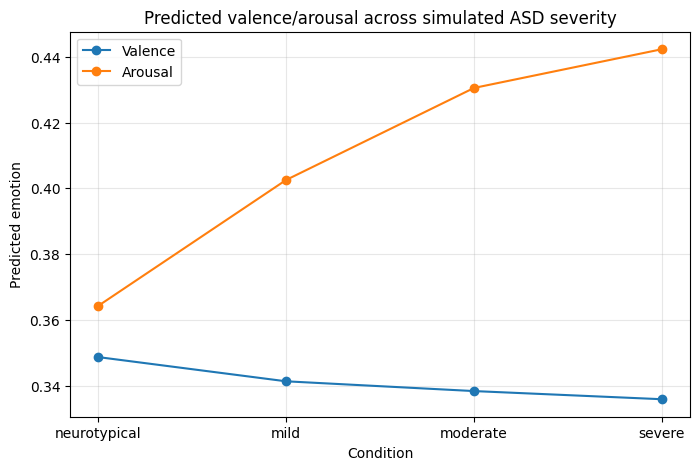

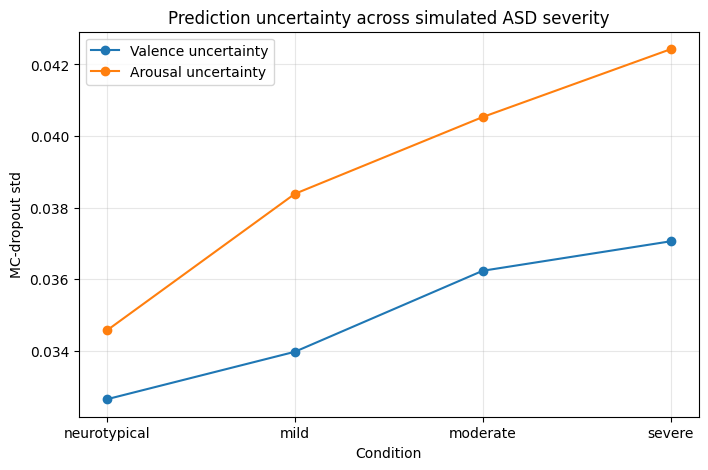

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results_df['condition'], results_df['valence_mean'], marker='o', label='Valence')
plt.plot(results_df['condition'], results_df['arousal_mean'], marker='o', label='Arousal')
plt.xlabel('Condition')
plt.ylabel('Predicted emotion')
plt.title('Predicted valence/arousal across simulated ASD severity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df['condition'], results_df['uncertainty_valence'], marker='o', label='Valence uncertainty')
plt.plot(results_df['condition'], results_df['uncertainty_arousal'], marker='o', label='Arousal uncertainty')
plt.xlabel('Condition')
plt.ylabel('MC-dropout std')
plt.title('Prediction uncertainty across simulated ASD severity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


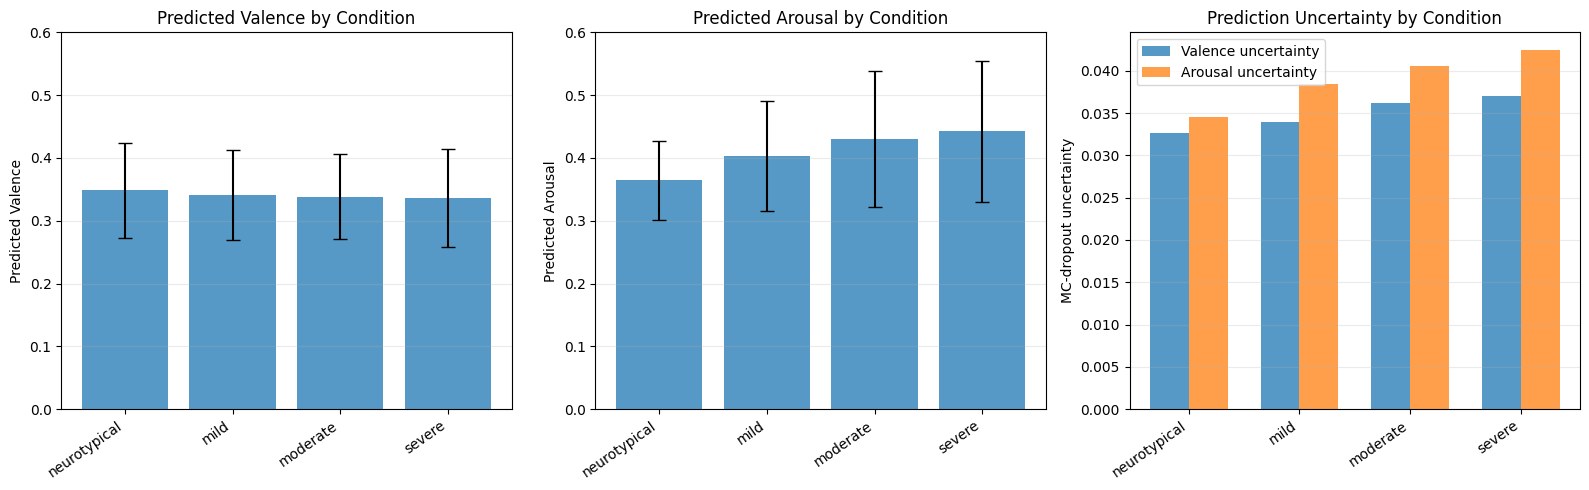

Saved plot: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/nt_vs_asd_comparison_meanstd_mlp_256_0.15_zlabel.png


In [ ]:
# Visualize NT vs ASD comparison
conditions = results_df["condition"].tolist()
x = np.arange(len(conditions))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valence comparison
axes[0].bar(
    x,
    results_df["valence_mean"],
    yerr=results_df["valence_std"],
    capsize=5,
    alpha=0.75
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions, rotation=35, ha="right")
axes[0].set_ylabel("Predicted Valence")
axes[0].set_title("Predicted Valence by Condition")
axes[0].set_ylim([0, 0.6])
axes[0].grid(axis="y", alpha=0.25)

# Arousal comparison
axes[1].bar(
    x,
    results_df["arousal_mean"],
    yerr=results_df["arousal_std"],
    capsize=5,
    alpha=0.75
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions, rotation=35, ha="right")
axes[1].set_ylabel("Predicted Arousal")
axes[1].set_title("Predicted Arousal by Condition")
axes[1].set_ylim([0, 0.6])
axes[1].grid(axis="y", alpha=0.25)

# Uncertainty comparison
width = 0.35
axes[2].bar(
    x - width / 2,
    results_df["uncertainty_valence"],
    width,
    label="Valence uncertainty",
    alpha=0.75
)
axes[2].bar(
    x + width / 2,
    results_df["uncertainty_arousal"],
    width,
    label="Arousal uncertainty",
    alpha=0.75
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(conditions, rotation=35, ha="right")
axes[2].set_ylabel("MC-dropout uncertainty")
axes[2].set_title("Prediction Uncertainty by Condition")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()

plot_path = os.path.join(
    RESULTS_DIR,
    f"nt_vs_asd_comparison_{RUN_ID}.png"
)
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## 20. Music Generation

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this to match the model/run you are using
# results_df_path_insert = "meanstd_mlp_256_0.15_zlabel"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MIDI_DIR, exist_ok=True)

print("Results directory:", RESULTS_DIR)
print("MIDI directory:", MIDI_DIR)
print("Run name:", RUN_ID)

display(results_df)

Results directory: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results
MIDI directory: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/midi_output
Run name: meanstd_mlp_256_0.15_zlabel


,condition,valence_mean,valence_std,arousal_mean,arousal_std,uncertainty_valence,uncertainty_arousal
0,neurotypical,0.348650,0.075633,0.364231,0.062481,0.032645,0.034569
1,mild,0.341284,0.071319,0.402524,0.087567,0.033971,0.038385
2,moderate,0.338313,0.067149,0.430514,0.108412,0.036235,0.040531
3,severe,0.335834,0.078285,0.442296,0.112387,0.037058,0.042426


In [ ]:
def emotion_to_music_params_calibrated(valence, arousal, results_df):
    """
    Calibrated music mapping for this experiment.

    The model's valence/arousal predictions are compressed into a narrow range,
    so this function maps relative changes across conditions into clearer
    musical differences.

    It does NOT change the model predictions.
    It only changes how predictions are translated into music parameters.
    """

    valence = float(np.clip(valence, 0.0, 1.0))
    arousal = float(np.clip(arousal, 0.0, 1.0))

    # Relative arousal position among the four conditions
    a_min = float(results_df["arousal_mean"].min())
    a_max = float(results_df["arousal_mean"].max())

    if abs(a_max - a_min) < 1e-8:
        arousal_rel = 0.5
    else:
        arousal_rel = (arousal - a_min) / (a_max - a_min)

    arousal_rel = float(np.clip(arousal_rel, 0.0, 1.0))

    # alternative scaling approach that does not have dataset-dependent normalization
    # arousal_rel = (arousal - 0.3) / (0.6 - 0.3)

    # Relative valence position among the four conditions
    v_min = float(results_df["valence_mean"].min())
    v_max = float(results_df["valence_mean"].max())

    if abs(v_max - v_min) < 1e-8:
        valence_rel = 0.5
    else:
        valence_rel = (valence - v_min) / (v_max - v_min)

    valence_rel = float(np.clip(valence_rel, 0.0, 1.0))

    # Make tempo differences clearer
    tempo = int(round(75 + 45 * arousal_rel))  # 75–120 BPM

    # Make note density differences clearer
    note_density = 0.7 + 1.1 * arousal_rel    # 0.7–1.8

    # Use relative valence/arousal to choose scale/mood
    if arousal_rel < 0.25:
        scale = "major_pentatonic"
        mood = "calm / stable"
    elif arousal_rel < 0.55:
        scale = "dorian"
        mood = "reflective / building"
    elif arousal_rel < 0.80:
        scale = "minor"
        mood = "tense / active"
    else:
        scale = "phrygian"
        mood = "intense / high-arousal"


    return {
        "tempo": tempo,
        "note_density": float(note_density),
        "scale": scale,
        "mood": mood,
        "valence": valence,
        "arousal": arousal,
        "valence_relative": valence_rel,
        "arousal_relative": arousal_rel
    }


music_params_by_condition = {}

print("Analyzing music parameter differences...\n")

for _, row in results_df.iterrows():
    condition = row["condition"]

    params = emotion_to_music_params_calibrated(
        row["valence_mean"],
        row["arousal_mean"],
        results_df
    )

    music_params_by_condition[condition] = params

    print(f"{condition.upper()}:")
    print(f"  Valence: {params['valence']:.3f}")
    print(f"  Arousal: {params['arousal']:.3f}")
    print(f"  Relative valence: {params['valence_relative']:.3f}")
    print(f"  Relative arousal: {params['arousal_relative']:.3f}")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Mood: {params['mood']}")
    print(f"  Note density: {params['note_density']:.2f}")
    print()

Analyzing music parameter differences...

NEUROTYPICAL:
  Valence: 0.349
  Arousal: 0.364
  Relative valence: 1.000
  Relative arousal: 0.000
  Tempo: 75 BPM
  Scale: major_pentatonic
  Mood: calm / stable
  Note density: 0.70

MILD:
  Valence: 0.341
  Arousal: 0.403
  Relative valence: 0.425
  Relative arousal: 0.491
  Tempo: 97 BPM
  Scale: dorian
  Mood: reflective / building
  Note density: 1.24

MODERATE:
  Valence: 0.338
  Arousal: 0.431
  Relative valence: 0.193
  Relative arousal: 0.849
  Tempo: 113 BPM
  Scale: phrygian
  Mood: intense / high-arousal
  Note density: 1.63

SEVERE:
  Valence: 0.336
  Arousal: 0.442
  Relative valence: 0.000
  Relative arousal: 1.000
  Tempo: 120 BPM
  Scale: phrygian
  Mood: intense / high-arousal
  Note density: 1.80



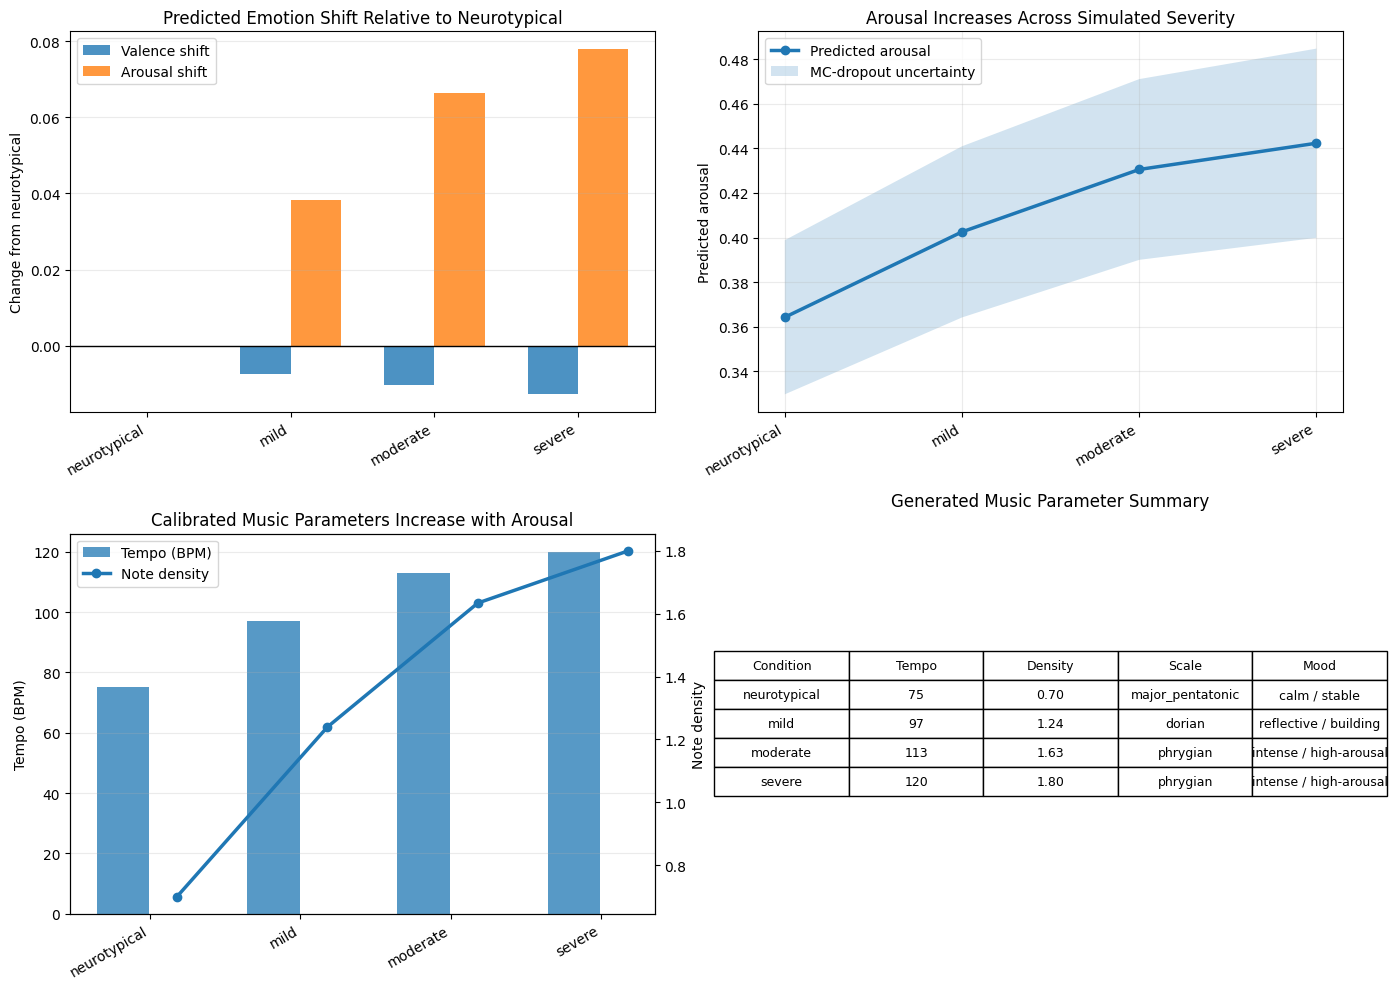

Saved clearer summary plot: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/clear_music_generation_summary_meanstd_mlp_256_0.15_zlabel.png


,condition,valence_mean,arousal_mean,delta_valence,delta_arousal,uncertainty_valence,uncertainty_arousal
0,neurotypical,0.348650,0.364231,0.000000,0.000000,0.032645,0.034569
1,mild,0.341284,0.402524,-0.007366,0.038293,0.033971,0.038385
2,moderate,0.338313,0.430514,-0.010337,0.066283,0.036235,0.040531
3,severe,0.335834,0.442296,-0.012816,0.078065,0.037059,0.042426


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Prepare data
# -----------------------------
conditions = results_df["condition"].tolist()
x = np.arange(len(conditions))

baseline = results_df[results_df["condition"] == "neurotypical"].iloc[0]

plot_df = results_df.copy()
plot_df["delta_valence"] = plot_df["valence_mean"] - baseline["valence_mean"]
plot_df["delta_arousal"] = plot_df["arousal_mean"] - baseline["arousal_mean"]
plot_df["delta_uncertainty_valence"] = plot_df["uncertainty_valence"] - baseline["uncertainty_valence"]
plot_df["delta_uncertainty_arousal"] = plot_df["uncertainty_arousal"] - baseline["uncertainty_arousal"]

tempos = np.array([music_params_by_condition[c]["tempo"] for c in conditions])
densities = np.array([music_params_by_condition[c]["note_density"] for c in conditions])
scales = [music_params_by_condition[c]["scale"] for c in conditions]
moods = [music_params_by_condition[c]["mood"] for c in conditions]

tempo_delta = tempos - tempos[0]
density_delta = densities - densities[0]

condition_colors = {
    "neurotypical": "tab:blue",
    "mild": "tab:green",
    "moderate": "tab:orange",
    "severe": "tab:red"
}
colors = [condition_colors.get(c, "gray") for c in conditions]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Emotion shift from neurotypical baseline
width = 0.35
axes[0, 0].bar(
    x - width / 2,
    plot_df["delta_valence"],
    width,
    label="Valence shift",
    alpha=0.8
)
axes[0, 0].bar(
    x + width / 2,
    plot_df["delta_arousal"],
    width,
    label="Arousal shift",
    alpha=0.8
)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(conditions, rotation=30, ha="right")
axes[0, 0].set_ylabel("Change from neurotypical")
axes[0, 0].set_title("Predicted Emotion Shift Relative to Neurotypical")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", alpha=0.25)

# 2. Arousal trend and uncertainty
axes[0, 1].plot(
    x,
    results_df["arousal_mean"],
    marker="o",
    linewidth=2.5,
    label="Predicted arousal"
)
axes[0, 1].fill_between(
    x,
    results_df["arousal_mean"] - results_df["uncertainty_arousal"],
    results_df["arousal_mean"] + results_df["uncertainty_arousal"],
    alpha=0.2,
    label="MC-dropout uncertainty"
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(conditions, rotation=30, ha="right")
axes[0, 1].set_ylabel("Predicted arousal")
axes[0, 1].set_title("Arousal Increases Across Simulated Severity")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# 3. Calibrated music tempo and density
ax1 = axes[1, 0]
ax2 = ax1.twinx()

bars = ax1.bar(
    x - 0.18,
    tempos,
    width=0.35,
    alpha=0.75,
    label="Tempo (BPM)"
)

line = ax2.plot(
    x + 0.18,
    densities,
    marker="o",
    linewidth=2.5,
    label="Note density"
)

ax1.set_xticks(x)
ax1.set_xticklabels(conditions, rotation=30, ha="right")
ax1.set_ylabel("Tempo (BPM)")
ax2.set_ylabel("Note density")
ax1.set_title("Calibrated Music Parameters Increase with Arousal")
ax1.grid(axis="y", alpha=0.25)

# Combined legend for twin axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

# 4. Music interpretation table
axes[1, 1].axis("off")

table_data = []
for c, tempo, density, scale, mood in zip(conditions, tempos, densities, scales, moods):
    table_data.append([
        c,
        f"{tempo}",
        f"{density:.2f}",
        scale,
        mood
    ])

table = axes[1, 1].table(
    cellText=table_data,
    colLabels=["Condition", "Tempo", "Density", "Scale", "Mood"],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.15, 1.6)

axes[1, 1].set_title("Generated Music Parameter Summary", pad=20)

plt.tight_layout()

clear_summary_path = os.path.join(
    RESULTS_DIR,
    f"clear_music_generation_summary_{RUN_ID}.png"
)

plt.savefig(clear_summary_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved clearer summary plot:", clear_summary_path)

display(plot_df[[
    "condition",
    "valence_mean",
    "arousal_mean",
    "delta_valence",
    "delta_arousal",
    "uncertainty_valence",
    "uncertainty_arousal"
]])

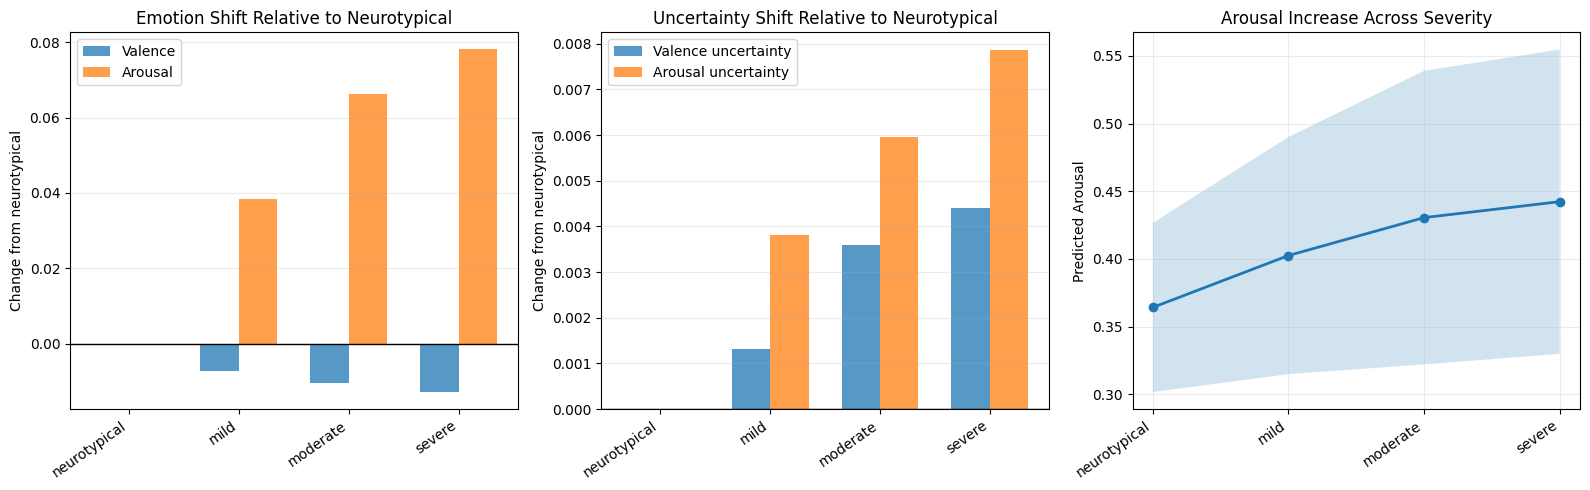

Saved delta plot: /content/drive/MyDrive/2025/ASD_Project/DEAP_Data/results/nt_vs_asd_delta_from_baseline_meanstd_mlp_256_0.15_zlabel.png


,condition,valence_mean,valence_std,arousal_mean,arousal_std,uncertainty_valence,uncertainty_arousal,delta_valence,delta_arousal,delta_uncertainty_valence,delta_uncertainty_arousal
0,neurotypical,0.348650,0.075633,0.364231,0.062481,0.032645,0.034569,0.000000,0.000000,0.000000,0.000000
1,mild,0.341284,0.071319,0.402524,0.087567,0.033971,0.038385,-0.007366,0.038293,0.001326,0.003816
2,moderate,0.338313,0.067149,0.430514,0.108412,0.036235,0.040531,-0.010337,0.066283,0.003590,0.005962
3,severe,0.335834,0.078285,0.442296,0.112387,0.037059,0.042426,-0.012816,0.078065,0.004413,0.007857


In [ ]:
# Plot changes relative to neurotypical baseline
baseline = results_df[results_df["condition"] == "neurotypical"].iloc[0]

delta_df = results_df.copy()
delta_df["delta_valence"] = delta_df["valence_mean"] - baseline["valence_mean"]
delta_df["delta_arousal"] = delta_df["arousal_mean"] - baseline["arousal_mean"]
delta_df["delta_uncertainty_valence"] = delta_df["uncertainty_valence"] - baseline["uncertainty_valence"]
delta_df["delta_uncertainty_arousal"] = delta_df["uncertainty_arousal"] - baseline["uncertainty_arousal"]

conditions = delta_df["condition"].tolist()
x = np.arange(len(conditions))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Delta valence/arousal
width = 0.35
axes[0].bar(x - width/2, delta_df["delta_valence"], width, label="Valence", alpha=0.75)
axes[0].bar(x + width/2, delta_df["delta_arousal"], width, label="Arousal", alpha=0.75)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions, rotation=35, ha="right")
axes[0].set_ylabel("Change from neurotypical")
axes[0].set_title("Emotion Shift Relative to Neurotypical")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

# Delta uncertainty
axes[1].bar(x - width/2, delta_df["delta_uncertainty_valence"], width, label="Valence uncertainty", alpha=0.75)
axes[1].bar(x + width/2, delta_df["delta_uncertainty_arousal"], width, label="Arousal uncertainty", alpha=0.75)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(conditions, rotation=35, ha="right")
axes[1].set_ylabel("Change from neurotypical")
axes[1].set_title("Uncertainty Shift Relative to Neurotypical")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

# Arousal trend line
axes[2].plot(x, results_df["arousal_mean"], marker="o", linewidth=2)
axes[2].fill_between(
    x,
    results_df["arousal_mean"] - results_df["arousal_std"],
    results_df["arousal_mean"] + results_df["arousal_std"],
    alpha=0.2
)
axes[2].set_xticks(x)
axes[2].set_xticklabels(conditions, rotation=35, ha="right")
axes[2].set_ylabel("Predicted Arousal")
axes[2].set_title("Arousal Increase Across Severity")
axes[2].grid(alpha=0.25)

plt.tight_layout()

delta_plot_path = os.path.join(
    RESULTS_DIR,
    f"nt_vs_asd_delta_from_baseline_{RUN_ID}.png"
)

plt.savefig(delta_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved delta plot:", delta_plot_path)

display(delta_df)

In [ ]:
class TherapeuticMusicGenerator:
    """
    Generate therapeutic music based on predicted emotional state.

    Emotion-to-music mapping:
    - High valence + High arousal → Fast, major, complex (Happy)
    - High valence + Low arousal → Slow, major, simple (Peaceful)
    - Low valence + High arousal → Fast, minor, complex (Anxious/Tense)
    - Low valence + Low arousal → Slow, minor, simple (Sad)
    """

    def __init__(self):
        # Musical scales
        self.scales = {
            'major': [0, 2, 4, 5, 7, 9, 11],
            'minor': [0, 2, 3, 5, 7, 8, 10],
            'dorian': [0, 2, 3, 5, 7, 9, 10],
            'mixolydian': [0, 2, 4, 5, 7, 9, 10],
            'pentatonic_major': [0, 2, 4, 7, 9],
            'pentatonic_minor': [0, 3, 5, 7, 10]
        }

        # Chord progressions by mood
        self.chord_progressions = {
            'happy': [[0, 4, 7], [5, 9, 12], [7, 11, 14], [0, 4, 7]],  # I-IV-V-I
            'peaceful': [[0, 4, 7], [5, 9, 12], [2, 5, 9], [0, 4, 7]],  # I-IV-ii-I
            'sad': [[0, 3, 7], [5, 8, 12], [7, 10, 14], [0, 3, 7]],  # i-iv-v-i
            'tense': [[0, 3, 7], [1, 4, 8], [7, 10, 14], [0, 3, 7]]  # i-bII-v-i
        }

        # Note durations (in beats)
        self.durations = {
            'whole': 4.0,
            'half': 2.0,
            'quarter': 1.0,
            'eighth': 0.5,
            'sixteenth': 0.25
        }

    def emotion_to_music_params(self, valence, arousal):
        """
        Map valence/arousal to musical parameters.

        Args:
            valence: 0-1 (negative to positive)
            arousal: 0-1 (calm to excited)

        Returns:
            dict of musical parameters
        """
        params = {}

        # Tempo: 60-140 BPM based on arousal
        params['tempo'] = int(60 + arousal * 80)

        # Note density: notes per beat
        params['note_density'] = 0.5 + arousal * 1.5  # 0.5 to 2.0

        # Scale/Mode selection
        # if valence > 0.6:
        #     params['scale'] = 'major' if arousal > 0.5 else 'pentatonic_major'
        # elif valence < 0.4:
        #     params['scale'] = 'minor' if arousal > 0.5 else 'pentatonic_minor'
        # else:
        #     params['scale'] = 'dorian' if arousal > 0.5 else 'mixolydian'

        # Scale / mode selection
        if valence >= 0.65:
            params['scale'] = 'major'
        elif valence <= 0.35:
            params['scale'] = 'minor'
        elif arousal < 0.55:
            params['scale'] = 'mixolydian'
        else:
            params['scale'] = 'dorian'

        # Mood category
        # if valence > 0.5 and arousal > 0.5:
        #     params['mood'] = 'happy'
        # elif valence > 0.5 and arousal <= 0.5:
        #     params['mood'] = 'peaceful'
        # elif valence <= 0.5 and arousal > 0.5:
        #     params['mood'] = 'tense'
        # else:
        #     params['mood'] = 'sad'

        # Mood category
        if arousal < 0.50:
            params['mood'] = 'peaceful'
        elif arousal < 0.75:
            params['mood'] = 'reflective'
        else:
            params['mood'] = 'tense'

        # Base pitch (MIDI note number)
        params['base_pitch'] = 60  # Middle C

        # Rhythmic complexity
        params['rhythmic_complexity'] = arousal  # 0-1

        # Harmonic complexity
        params['harmonic_complexity'] = 0.3 + valence * 0.4  # 0.3-0.7

        # Dynamics
        params['velocity_base'] = int(60 + arousal * 40)  # 60-100
        params['velocity_variation'] = int(arousal * 20)  # 0-20

        return params

    def generate_melody(self, params, duration=16, seed=42):
        """
        Generate a melody based on musical parameters.

        Args:
            params: Musical parameters from emotion_to_music_params
            duration: Duration in beats
            seed: Random seed

        Returns:
            List of (pitch, start_time, duration, velocity) tuples
        """
        rng = np.random.RandomState(seed)

        scale = self.scales[params['scale']]
        base_pitch = params['base_pitch']

        melody = []
        current_time = 0

        while current_time < duration:
            # Choose note duration based on complexity
            if params['rhythmic_complexity'] > 0.7:
                dur_choices = [0.25, 0.5, 0.5, 1.0]
            elif params['rhythmic_complexity'] > 0.4:
                dur_choices = [0.5, 0.5, 1.0, 1.0]
            else:
                dur_choices = [1.0, 1.0, 2.0, 2.0]

            note_dur = rng.choice(dur_choices)

            # Choose pitch from scale
            octave = rng.choice([0, 0, 12, 12, -12])  # Mostly in base octave
            scale_degree = rng.choice(len(scale))
            pitch = base_pitch + scale[scale_degree] + octave

            # Velocity with variation
            velocity = params['velocity_base'] + rng.randint(
                -params['velocity_variation'],
                params['velocity_variation'] + 1
            )
            velocity = np.clip(velocity, 40, 127)

            melody.append((pitch, current_time, note_dur, velocity))
            current_time += note_dur

        return melody

    def generate_harmony(self, params, melody):
        """
        Generate chord accompaniment.

        Args:
            params: Musical parameters
            melody: Generated melody

        Returns:
            List of chord events
        """
        progression = self.chord_progressions[params['mood']]
        base_pitch = params['base_pitch'] - 12  # One octave lower

        harmony = []
        chord_duration = 4.0  # One chord per bar

        total_duration = max(note[1] + note[2] for note in melody)
        current_time = 0
        chord_idx = 0

        while current_time < total_duration:
            chord = progression[chord_idx % len(progression)]
            velocity = int(params['velocity_base'] * 0.7)  # Softer than melody

            for interval in chord:
                pitch = base_pitch + interval
                harmony.append((pitch, current_time, chord_duration, velocity))

            current_time += chord_duration
            chord_idx += 1

        return harmony

    def create_midi(self, melody, harmony, params, filename):
        """
        Create MIDI file from melody and harmony.

        Args:
            melody: List of melody notes
            harmony: List of harmony chords
            params: Musical parameters (for tempo)
            filename: Output filename
        """
        midi = MIDIFile(2)  # Two tracks: melody and harmony

        # Track 0: Melody
        track_melody = 0
        midi.addTrackName(track_melody, 0, "Melody")
        midi.addTempo(track_melody, 0, params['tempo'])
        midi.addProgramChange(track_melody, 0, 0, 0)  # Piano

        for pitch, start, dur, vel in melody:
            midi.addNote(track_melody, 0, int(pitch), start, dur, int(vel))

        # Track 1: Harmony
        track_harmony = 1
        midi.addTrackName(track_harmony, 0, "Harmony")
        midi.addProgramChange(track_harmony, 1, 0, 0)  # Piano

        for pitch, start, dur, vel in harmony:
            midi.addNote(track_harmony, 1, int(pitch), start, dur, int(vel))

        # Write to file
        with open(filename, 'wb') as f:
            midi.writeFile(f)

        return filename

    def generate_therapeutic_music(self, valence, arousal, filename, duration=16):
        """
        Full pipeline: emotion → parameters → melody → harmony → MIDI.

        Args:
            valence: Predicted valence (0-1)
            arousal: Predicted arousal (0-1)
            filename: Output MIDI filename
            duration: Music duration in beats

        Returns:
            dict with parameters and filename
        """
        # Map emotion to music parameters
        params = self.emotion_to_music_params(valence, arousal)

        # Generate music
        melody = self.generate_melody(params, duration)
        harmony = self.generate_harmony(params, melody)

        # Create MIDI
        self.create_midi(melody, harmony, params, filename)

        return {
            'valence': valence,
            'arousal': arousal,
            'parameters': params,
            'filename': filename
        }


# Initialize music generator
music_gen = TherapeuticMusicGenerator()
print("TherapeuticMusicGenerator initialized")

TherapeuticMusicGenerator initialized


In [ ]:
# Test music generation for different emotional states
test_emotions = [
    (0.8, 0.8, 'happy'),
    (0.8, 0.2, 'peaceful'),
    (0.2, 0.8, 'tense'),
    (0.2, 0.2, 'sad')
]

print("Music parameters for different emotional states:\n")
for valence, arousal, label in test_emotions:
    params = music_gen.emotion_to_music_params(valence, arousal)
    print(f"{label.upper()} (V={valence}, A={arousal}):")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Note density: {params['note_density']:.2f}")
    print(f"  Velocity: {params['velocity_base']}±{params['velocity_variation']}")
    print()

Music parameters for different emotional states:

HAPPY (V=0.8, A=0.8):
  Tempo: 124 BPM
  Scale: major
  Note density: 1.70
  Velocity: 92±16

PEACEFUL (V=0.8, A=0.2):
  Tempo: 76 BPM
  Scale: major
  Note density: 0.80
  Velocity: 68±4

TENSE (V=0.2, A=0.8):
  Tempo: 124 BPM
  Scale: minor
  Note density: 1.70
  Velocity: 92±16

SAD (V=0.2, A=0.2):
  Tempo: 76 BPM
  Scale: minor
  Note density: 0.80
  Velocity: 68±4



In [ ]:
def calibrate_predictions(valence, arousal, results_df):

    # vmin = results_df["valence_mean"].min()
    # vmax = results_df["valence_mean"].max()

    # amin = results_df["arousal_mean"].min()
    # amax = results_df["arousal_mean"].max()

    # if vmax == vmin:
    #     valence_rel = 0.5
    # else:
    #     valence_rel = (valence - vmin)/(vmax - vmin)

    # if amax == amin:
    #     arousal_rel = 0.5
    # else:
    #     arousal_rel = (arousal - amin)/(amax - amin)

    valence_rel = np.clip(
        (valence - V_LOW) / (V_HIGH - V_LOW),
        0.0,
        1.0
    )

    arousal_rel = np.clip(
        (arousal - A_LOW) / (A_HIGH - A_LOW),
        0.0,
        1.0
    )

    return valence_rel, arousal_rel

In [ ]:
music_params_by_condition = {}

for _, row in results_df.iterrows():

    condition = row['condition']

    v_rel, a_rel = calibrate_predictions(
        row["valence_mean"],
        row["arousal_mean"],
        results_df
    )

    params = music_gen.emotion_to_music_params(v_rel, a_rel)

    music_params_by_condition[condition] = params

    print(condition)
    print("Relative valence:", v_rel)
    print("Relative arousal:", a_rel)
    print(params)

    print(f"{condition.upper()}:")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Mood: {params['mood']}")
    print(f"  Note density: {params['note_density']:.2f}")
    print()

neurotypical
Relative valence: 0.5136582
Relative arousal: 0.45462367
{'tempo': 96, 'note_density': np.float32(1.1819355), 'scale': 'mixolydian', 'mood': 'peaceful', 'base_pitch': 60, 'rhythmic_complexity': np.float32(0.45462367), 'harmonic_complexity': np.float32(0.5054633), 'velocity_base': 78, 'velocity_variation': 9}
NEUROTYPICAL:
  Tempo: 96 BPM
  Scale: mixolydian
  Mood: peaceful
  Note density: 1.18

mild
Relative valence: 0.48599866
Relative arousal: 0.6223647
{'tempo': 109, 'note_density': np.float32(1.433547), 'scale': 'dorian', 'mood': 'reflective', 'base_pitch': 60, 'rhythmic_complexity': np.float32(0.6223647), 'harmonic_complexity': np.float32(0.4943995), 'velocity_base': 84, 'velocity_variation': 12}
MILD:
  Tempo: 109 BPM
  Scale: dorian
  Mood: reflective
  Note density: 1.43

moderate
Relative valence: 0.4748435
Relative arousal: 0.7449688
{'tempo': 119, 'note_density': np.float32(1.6174531), 'scale': 'dorian', 'mood': 'reflective', 'base_pitch': 60, 'rhythmic_complex

In [ ]:
for _, row in results_df.iterrows():

    condition = row["condition"]

    v_rel, a_rel = calibrate_predictions(
        row["valence_mean"],
        row["arousal_mean"],
        results_df
    )

    params = music_gen.emotion_to_music_params(v_rel, a_rel)

    print(condition)
    print("Relative valence:", v_rel)
    print("Relative arousal:", a_rel)
    print(params)

    print(f"{condition.upper()}:")
    print(f"  Tempo: {params['tempo']} BPM")
    print(f"  Scale: {params['scale']}")
    print(f"  Mood: {params['mood']}")

neurotypical
Relative valence: 0.5136582
Relative arousal: 0.45462367
{'tempo': 96, 'note_density': np.float32(1.1819355), 'scale': 'mixolydian', 'mood': 'peaceful', 'base_pitch': 60, 'rhythmic_complexity': np.float32(0.45462367), 'harmonic_complexity': np.float32(0.5054633), 'velocity_base': 78, 'velocity_variation': 9}
NEUROTYPICAL:
  Tempo: 96 BPM
  Scale: mixolydian
  Mood: peaceful
mild
Relative valence: 0.48599866
Relative arousal: 0.6223647
{'tempo': 109, 'note_density': np.float32(1.433547), 'scale': 'dorian', 'mood': 'reflective', 'base_pitch': 60, 'rhythmic_complexity': np.float32(0.6223647), 'harmonic_complexity': np.float32(0.4943995), 'velocity_base': 84, 'velocity_variation': 12}
MILD:
  Tempo: 109 BPM
  Scale: dorian
  Mood: reflective
moderate
Relative valence: 0.4748435
Relative arousal: 0.7449688
{'tempo': 119, 'note_density': np.float32(1.6174531), 'scale': 'dorian', 'mood': 'reflective', 'base_pitch': 60, 'rhythmic_complexity': np.float32(0.7449688), 'harmonic_compl